In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import xarray as xr
import numpy as np
import dask.array
# import cosima_cookbook as cc
import intake
from access_nri_intake.source.builders import AccessOm2Builder

from gsw import alpha, SA_from_SP, p_from_z, CT_from_pt, beta, sigma1, sigma0
# note these gsw numpy functions mean some care is needed to avoid memory issues in very high-res analysis 

## plotting
import matplotlib.pyplot as plt
from matplotlib import gridspec
import cmocean as cmo
import matplotlib.colors as col
import cartopy.crs as ccrs
import matplotlib.path as mpath
from matplotlib import rc
rc('text', usetex=False)
rc('xtick', labelsize=25) 
rc('ytick', labelsize=25) 
rc('axes', labelsize=25) 



from dask.distributed import Client

figdir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'

In [2]:
client = Client(threads_per_worker=1)
client.dashboard_link

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43835 instead
  warnings.warn(


'/proxy/43835/status'

### create Basal project part 2 intake:

In [3]:
# add experiments to my own intake:

# - control:
path_ctrl = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath"

# - basal No Gade: GPC029 (Basal)   
path_noBG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'

# - basal Gade: GPC023 (Basal_LH)   
path_BG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb'

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BGB = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine'

### SOFIA meltwater perturbation expts:
# - control:
path_ctrl_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126"

# - basal No Gade: GPC029 (Basal)   
path_noBG_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126"

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BGB_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126"

path_ctrl_antwater = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_antwater"
path_BGB_antwater = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_antwater"

# new control runs with Gadel line:
path_ctrl_BG = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_Gade"
path_ctrl_BG_antwater = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_Gade_sofia_antwater"
path_ctrl_antwater_BG = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_antwater_Gade"


#### run section below to build the datastore (in case not done before/update in model outputs)

In [4]:
%%time

builder = AccessOm2Builder(
    path=path_ctrl
).build()

builder.save(
    name="DSW_control", 
    description="Datastore for ACCESS-OM2 ryf9091 DSW control",
)


builder = AccessOm2Builder(
    path=path_noBG
).build()

builder.save(
    name="Basal", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal",
)

builder = AccessOm2Builder(
    path=path_BG,
).build()

builder.save(
    name="Basal_LH", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal_LH",
)

builder = AccessOm2Builder(
    path=path_BGB,
).build()

builder.save(
    name="Basal_LH_Brine", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal_LH_Brine",
)


builder = AccessOm2Builder(
    path=path_ctrl_sofia
).build()

builder.save(
    name="DSW_control_sofia", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA control (mbath21)",
)


builder = AccessOm2Builder(
    path=path_noBG_sofia
).build()

builder.save(
    name="Basal_sofia", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Basal rep.",
)


builder = AccessOm2Builder(
    path=path_BGB_sofia
).build()

builder.save(
    name="Basal_LH_Brine_sofia", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Basal_LH_Brine rep.",
)


builder = AccessOm2Builder(
    path=path_ctrl_antwater
).build()

builder.save(
    name="DSW_control_antwater", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Antwater control (mbath21)",
)


builder = AccessOm2Builder(
    path=path_BGB_antwater
).build()

builder.save(
    name="Basal_LH_Brine_antwater", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Antwater Basal_LH_Brine",
)


builder = AccessOm2Builder(
    path=path_ctrl_BG
).build()

builder.save(
    name="DSW_control_LH", 
    description="Datastore for ACCESS-OM2 ryf9091 control + Antwater applying Gade line (all runoff)",
)


builder = AccessOm2Builder(
    path=path_ctrl_BG_antwater
).build()

builder.save(
    name="DSW_control_LH_antwater", 
    description="Datastore for ACCESS-OM2 ryf9091 control applying Gade line only for Antwater anomaly",
)


builder = AccessOm2Builder(
    path=path_ctrl_antwater_BG
).build()

builder.save(
    name="DSW_control_antwater_LH", 
    description="Datastore for ACCESS-OM2 ryf9091 control applying Gade line only for Antwater anomaly",
)

Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH_Brine.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control_sofia.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_sofia.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH_Brine_sofia.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control_antwater.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH_Brine_antwater.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control_LH.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control_LH_antwater.json
Successfu

#### loading intake datastore for individual experiments:

In [4]:
cat = intake.open_esm_datastore(
    "./DSW_control.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_noBG = intake.open_esm_datastore(
    "./Basal.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_BG = intake.open_esm_datastore(
    "./Basal_LH.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_BGB = intake.open_esm_datastore(
    "./Basal_LH_Brine.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_sofia = intake.open_esm_datastore(
    "./DSW_control_sofia.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important 
)

cat_noBG_sofia = intake.open_esm_datastore(
    "./Basal_sofia.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_BGB_sofia = intake.open_esm_datastore(
    "./Basal_LH_Brine_sofia.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_antwater = intake.open_esm_datastore(
    "./DSW_control_antwater.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_BGB_antwater = intake.open_esm_datastore(
    "./Basal_LH_Brine_antwater.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_SSStest = intake.open_esm_datastore(
    "./DSW_control_noSSSrest.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_ctrlBG = intake.open_esm_datastore(
    "./DSW_control_LH.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_ctrlBG_antwater = intake.open_esm_datastore(
    "./DSW_control_LH_antwater.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_ctrl_antwater_BG = intake.open_esm_datastore(
    "./DSW_control_antwater_LH.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

### Define time period and slice for SO:

In [5]:
# Make sure these match the available restarts:
start_time='1917-01-01'
end_time='1919-12-31'
time_slice = slice(start_time,end_time)
lat_slice  = slice(-80,-59)


#### load temp/salt, runoff, basal_fwflx2d, SSS restoring fluxes

In [6]:
## plot temperature all experiments:

t1 = cat.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t2 = cat_noBG.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t3 = cat_BGB.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)

t1s = cat_sofia.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t2s = cat_noBG_sofia.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t3s = cat_BGB_sofia.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)

t1a = cat_antwater.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t3a = cat_BGB_antwater.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t1b = cat_ctrlBG.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t1a_b = cat_ctrlBG_antwater.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t1a_c = cat_ctrl_antwater_BG.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

In [7]:
## plot salinity all experiments:

s1 = cat.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s2 = cat_noBG.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s3 = cat_BGB.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s1s = cat_sofia.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s2s = cat_noBG_sofia.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s3s = cat_BGB_sofia.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)

s1a = cat_antwater.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s3a = cat_BGB_antwater.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)

s1b = cat_ctrlBG.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s1a_b = cat_ctrlBG_antwater.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s1a_c = cat_ctrl_antwater_BG.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

### bottom temperature/salinity maps:

In [8]:
%%time

##1. define wet points from control simulation
wet = t1a.isel(time=0).notnull()  # (st_ocean, yt_ocean, xt_ocean) of booleans

##2. calculate T_bottom for each simulation & select time pediod
t1_bottom = t1.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')   # (time, yt_ocean, xt_ocean)
t1a_bottom = t1a.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')   # (time, yt_ocean, xt_ocean)
t1b_bottom = t1b.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')   # (time, yt_ocean, xt_ocean)
t1a_b_bottom = t1a_b.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')   # (time, yt_ocean, xt_ocean)
t1a_c_bottom = t1a_c.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')   # (time, yt_ocean, xt_ocean)
t3_bottom = t3.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')   # (time, yt_ocean, xt_ocean)
t3a_bottom = t3a.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')   # (time, yt_ocean, xt_ocean)


CPU times: user 11.3 s, sys: 883 ms, total: 12.2 s
Wall time: 12.2 s


In [9]:
t1a_c_bottom = t1a_c.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')   # (time, yt_ocean, xt_ocean)


In [10]:
%%time
t1_bottom.load()
t1a_bottom.load() 
t1b_bottom.load()
t1a_b_bottom.load() 
t1a_c_bottom.load()
t3_bottom.load()
t3a_bottom.load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 67.26 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 25.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/cli

CPU times: user 43min 25s, sys: 2min 39s, total: 46min 4s
Wall time: 47min 5s


<xarray.Dataset> Size: 39MB
Dimensions:   (xt_ocean: 3600, yt_ocean: 2700)
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
    st_ocean  float64 8B 5.709e+03
Data variables:
    temp      (yt_ocean, xt_ocean) float32 39MB nan nan nan nan ... nan nan nan

In [11]:
wetS = s1.isel(time=0).notnull()  # (st_ocean, yt_ocean, xt_ocean) of booleans

s1_bottom = s1.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')    # (time, yt_ocean, xt_ocean)
s1a_bottom = s1a.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')    # (time, yt_ocean, xt_ocean)
s1b_bottom = s1b.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')    # (time, yt_ocean, xt_ocean)
s1a_b_bottom = s1a_b.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')    # (time, yt_ocean, xt_ocean)
s1a_c_bottom = s1a_c.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')    # (time, yt_ocean, xt_ocean)
s3_bottom = s3.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')    # (time, yt_ocean, xt_ocean)
s3a_bottom = s3a.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time)).mean('time')    # (time, yt_ocean, xt_ocean)


In [12]:
%%time

s1_bottom.load()
s1a_bottom.load()
s1b_bottom.load()
s1a_b_bottom.load()
s1a_c_bottom.load()
s3_bottom.load()
s3a_bottom.load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 61.30 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 39.16 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/cli

CPU times: user 45min 21s, sys: 2min 40s, total: 48min 2s
Wall time: 49min 5s


<xarray.Dataset> Size: 39MB
Dimensions:   (xt_ocean: 3600, yt_ocean: 2700)
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
    st_ocean  float64 8B 5.709e+03
Data variables:
    salt      (yt_ocean, xt_ocean) float32 39MB nan nan nan nan ... nan nan nan

### Include 4 DSW regions maps:

In [13]:
# ---------------------------------------------------------
# Define regions
# ---------------------------------------------------------
regions = {
    "Weddell Sea": {
        "xlim": (-65, -10),
        "ylim": (-79, -70),
        "transect_latlim": (-78, -71)
    },

    "Prydz Bay": {
        "xlim": (60, 80),
        "ylim": (-70, -65),
        "transect_latlim": (-68, -66.5)
    },

    "Ross Sea": {
        "xlim": (-200, -150),
        "ylim": (-79, -70),
        "transect_latlim": (-77.8, -70)
    },

    "Adélie Land": {
        "xlim": (-238, -203),
        "ylim": (-69.1, -63),
        "transect_latlim": (-66.7, -65.3)
    }
}

In [44]:
# ---------------------------------------------------------
# Define temperature/salinity anomaly maps
# ---------------------------------------------------------

Atemp = t1a_bottom.sel(yt_ocean = slice(-80, -59)).temp- \
                   t1_bottom.sel(yt_ocean = slice(-80, -59)).temp    # control_antwater - control
Btemp = t1a_b_bottom.sel(yt_ocean = slice(-80, -59)).temp- \
                   t1b_bottom.sel(yt_ocean = slice(-80, -59)).temp    # control_LH_antwater - control_LH
Ctemp = t1a_c_bottom.sel(yt_ocean = slice(-80, -59)).temp- \
                   t1_bottom.sel(yt_ocean = slice(-80, -59)).temp    # control_antwater_LH - control
Dtemp = t3a_bottom.sel(yt_ocean = slice(-80, -59)).temp- \
                   t3_bottom.sel(yt_ocean = slice(-80, -59)).temp    # basal_LH_br_antwater - basal_LH_br


Asalt = s1a_bottom.sel(yt_ocean = slice(-80, -59)).salt- \
                   s1_bottom.sel(yt_ocean = slice(-80, -59)).salt    # control_antwater - control
Bsalt = s1a_b_bottom.sel(yt_ocean = slice(-80, -59)).salt- \
                   s1b_bottom.sel(yt_ocean = slice(-80, -59)).salt    # control_LH_antwater - control_LH
Csalt = s1a_c_bottom.sel(yt_ocean = slice(-80, -59)).salt- \
                   s1_bottom.sel(yt_ocean = slice(-80, -59)).salt    # control_antwater_LH - control
Dsalt = s3a_bottom.sel(yt_ocean = slice(-80, -59)).salt- \
                   s3_bottom.sel(yt_ocean = slice(-80, -59)).salt    # basal_LH_br_antwater - basal_LH_br


In [45]:
# ============================================================
# Define temp/salt anomaly transects
# ============================================================

section_coords = {}
temp_cross = {}
salt_cross = {}

transect_lons = {
    "Weddell Sea": -50,
    "Prydz Bay": 69,
    "Ross Sea": -188,
    "Adélie Land": -218,
}

for region, lon in transect_lons.items():

    section = (
    t1a.isel(time=-1)
       .sel(yt_ocean=lat_slice)
       .sel(xt_ocean=lon, method='nearest')
    )

    section_coords[region] = {
        "lon": float(section.xt_ocean),
        "lat": section.yt_ocean,
        "z": section.st_ocean
    }

    temp_cross[region] = {
        "A": t1a.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').temp
        - t1.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').temp,

        "B": t1a_b.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').temp
        - t1b.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').temp,

        "C": t1a_c.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').temp
        - t1.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').temp,

        "D": t3a.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').temp
        - t3.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').temp
    }

    salt_cross[region] = {
        "A": s1a.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').salt
        - s1.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').salt,

        "B": s1a_b.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').salt
        - s1b.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').salt,

        "C": s1a_c.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').salt
        - s1.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').salt,

        "D": s3a.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').salt
        - s3.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat_slice, time=slice(start_time,end_time)
        ).mean('time').salt
    }



In [46]:
t1.yt_ocean

<xarray.DataArray 'yt_ocean' (yt_ocean: 2700)> Size: 22kB
array([-81.108632, -81.066392, -81.024153, ...,  89.894417,  89.936657,
        89.978896])
Coordinates:
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
Attributes:
    long_name:       tcell latitude
    units:           degrees_N
    cartesian_axis:  Y

In [47]:
## test contours+land mask
ht = cat.search(variable='ht').to_dask(decode_timedelta=True)
ht = ht.sel(yt_ocean = slice(-90, -59))
land_mask = (ht*0).fillna(1)
yt_ocean_da = ht.yt_ocean#.values
xt_ocean_da = ht.xt_ocean#.values


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


In [48]:
def shelf_mask_isobath(var):
    '''
    Masks ACCESS-OM2-01 variables by the region polewards of the 1000m isobath as computed using 
    a script contributed by Adele Morrison.
    Only to be used with ACCESS-OM2-0.1 output!
    '''
    contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
    
    shelf_mask = contour_file['contour_masked_above']
    yt_ocean = contour_file['yt_ocean']
    xt_ocean = contour_file['xt_ocean']
    
    # in this file the points along the isobath are given a positive value, the points outside (northwards) 
    # of the isobath are given a value of -100 and all the points on the continental shelf have a value of 0 
    # so we mask for the 0 values 
    shelf_mask[np.where(shelf_mask!=0)] = np.nan
    shelf_mask = shelf_mask+1
    shelf_map = np.nan_to_num(shelf_mask)
    shelf_mask = xr.DataArray(shelf_mask, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])
    shelf_map = xr.DataArray(shelf_map, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])
    
    # then we want to multiply the variable with the mask so we need to account for the shape of the mask. 
    # The mask uses a northern cutoff of 59S.
    masked_var = var.sel(yt_ocean = slice(-90, -59.03)) * shelf_mask
    return masked_var, shelf_map

ht_shelf , shelf_mask = shelf_mask_isobath(ht)


In [49]:
# ============================================================
# 2. Helper: slice longitude (normal or wrapped)
# ============================================================
def slice_lon(xlim, data_lat):
    # Case A: simple range
    if isinstance(xlim, tuple):
        x = xt_ocean_da.sel(xt_ocean=slice(xlim[0], xlim[1]))
        d = data_lat.sel(xt_ocean=slice(xlim[0], xlim[1]))
        return x, d

    # Case B: wrapped range (list of two ranges)
    parts_x = []
    parts_d = []
    for lo, hi in xlim:
        parts_x.append(xt_ocean_da.sel(xt_ocean=slice(lo, hi)))
        parts_d.append(data_lat.sel(xt_ocean=slice(lo, hi)))

    return xr.concat(parts_x, dim="xt_ocean"), xr.concat(parts_d, dim="xt_ocean")

# ============================================================
# 3. Panel plotting Map function
# ============================================================
def plot_panel(ax, data, title, xlim, ylim, vmin, vmax, cmap, transect_lon=None,transect_latlim=None,lon_point=None,lat_point=None):

    # Slice latitude
    data_lat = data.sel(yt_ocean=slice(ylim[0], ylim[1]))
    y = yt_ocean_da.sel(yt_ocean=slice(ylim[0], ylim[1]))

    # Slice longitude (handles wrapped)
    x, d = slice_lon(xlim, data_lat)

    # Slice masks the same way
    land_lat = land_mask['ht'].sel(yt_ocean=slice(ylim[0], ylim[1]))
    shelf_lat = shelf_mask.sel(yt_ocean=slice(ylim[0], ylim[1]))

    land_x, land_d = slice_lon(xlim, land_lat)
    shelf_x, shelf_d = slice_lon(xlim, shelf_lat)

    # Plot
    # m = ax.pcolormesh(x, y, d, vmin=vmin, vmax=vmax,
    #                   cmap=cmap, shading='auto')
    m = ax.contourf(
        x, y, d,
        levels=np.linspace(vmin, vmax, 21),cmap=cmap)

    ax.contourf(land_x, y, land_d, [0.9, 1],
                colors='darkgray', alpha=0.6)
    ax.contour(land_x, y, land_d, [0, 1],
               colors='darkgray', alpha=1)
    ax.contour(shelf_x, y, shelf_d, [0, 1],
               colors='k', alpha=0.3)

    # Axis limits
    ax.set_ylim(ylim)

    if isinstance(xlim, tuple):
        ax.set_xlim(xlim)
    else:
        # wrapped: e.g. [(81,360),(0,79)] → xlim = (81, 360+79)
        ax.set_xlim(xlim[0][0], 360 + xlim[1][1])

    # Transect location
    if transect_lon is not None and transect_latlim is not None:
        ax.plot(
            [transect_lon, transect_lon],
            [transect_latlim[0], transect_latlim[1]],
            color='k',
            linestyle='--',
            linewidth=2,
            zorder=10
        )

    # profile location:
    # if transect_lon is not None and transect_latlim is not None:
    #     ax.plot(lon_point, lat_point,'o',
    #         color='limegreen',
    #         zorder=10
    #     )

    ax.set_title(title, fontsize=22)
    ax.tick_params(axis='both', labelsize=16)

    return m

# ============================================================
# 5. Panel plotting Transect function
# ============================================================

def plot_section(ax, lat, z, data, title, vmin, vmax, cmap, xlim):

    ax.set_facecolor('lightgray')
    
    m = ax.contourf(
        lat, z, data,
        levels=np.linspace(vmin, vmax, 21),
        cmap=cmap,
        extend='both'
    )

    ax.invert_yaxis()
    ax.set_xlim(lims["transect_latlim"])
        
    ax.set_title(title, fontsize=22)
    ax.tick_params(axis='both', labelsize=16)

    return m

#### Separated figures for each region (and #not including transects):

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 21.82 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 17.48 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/cli

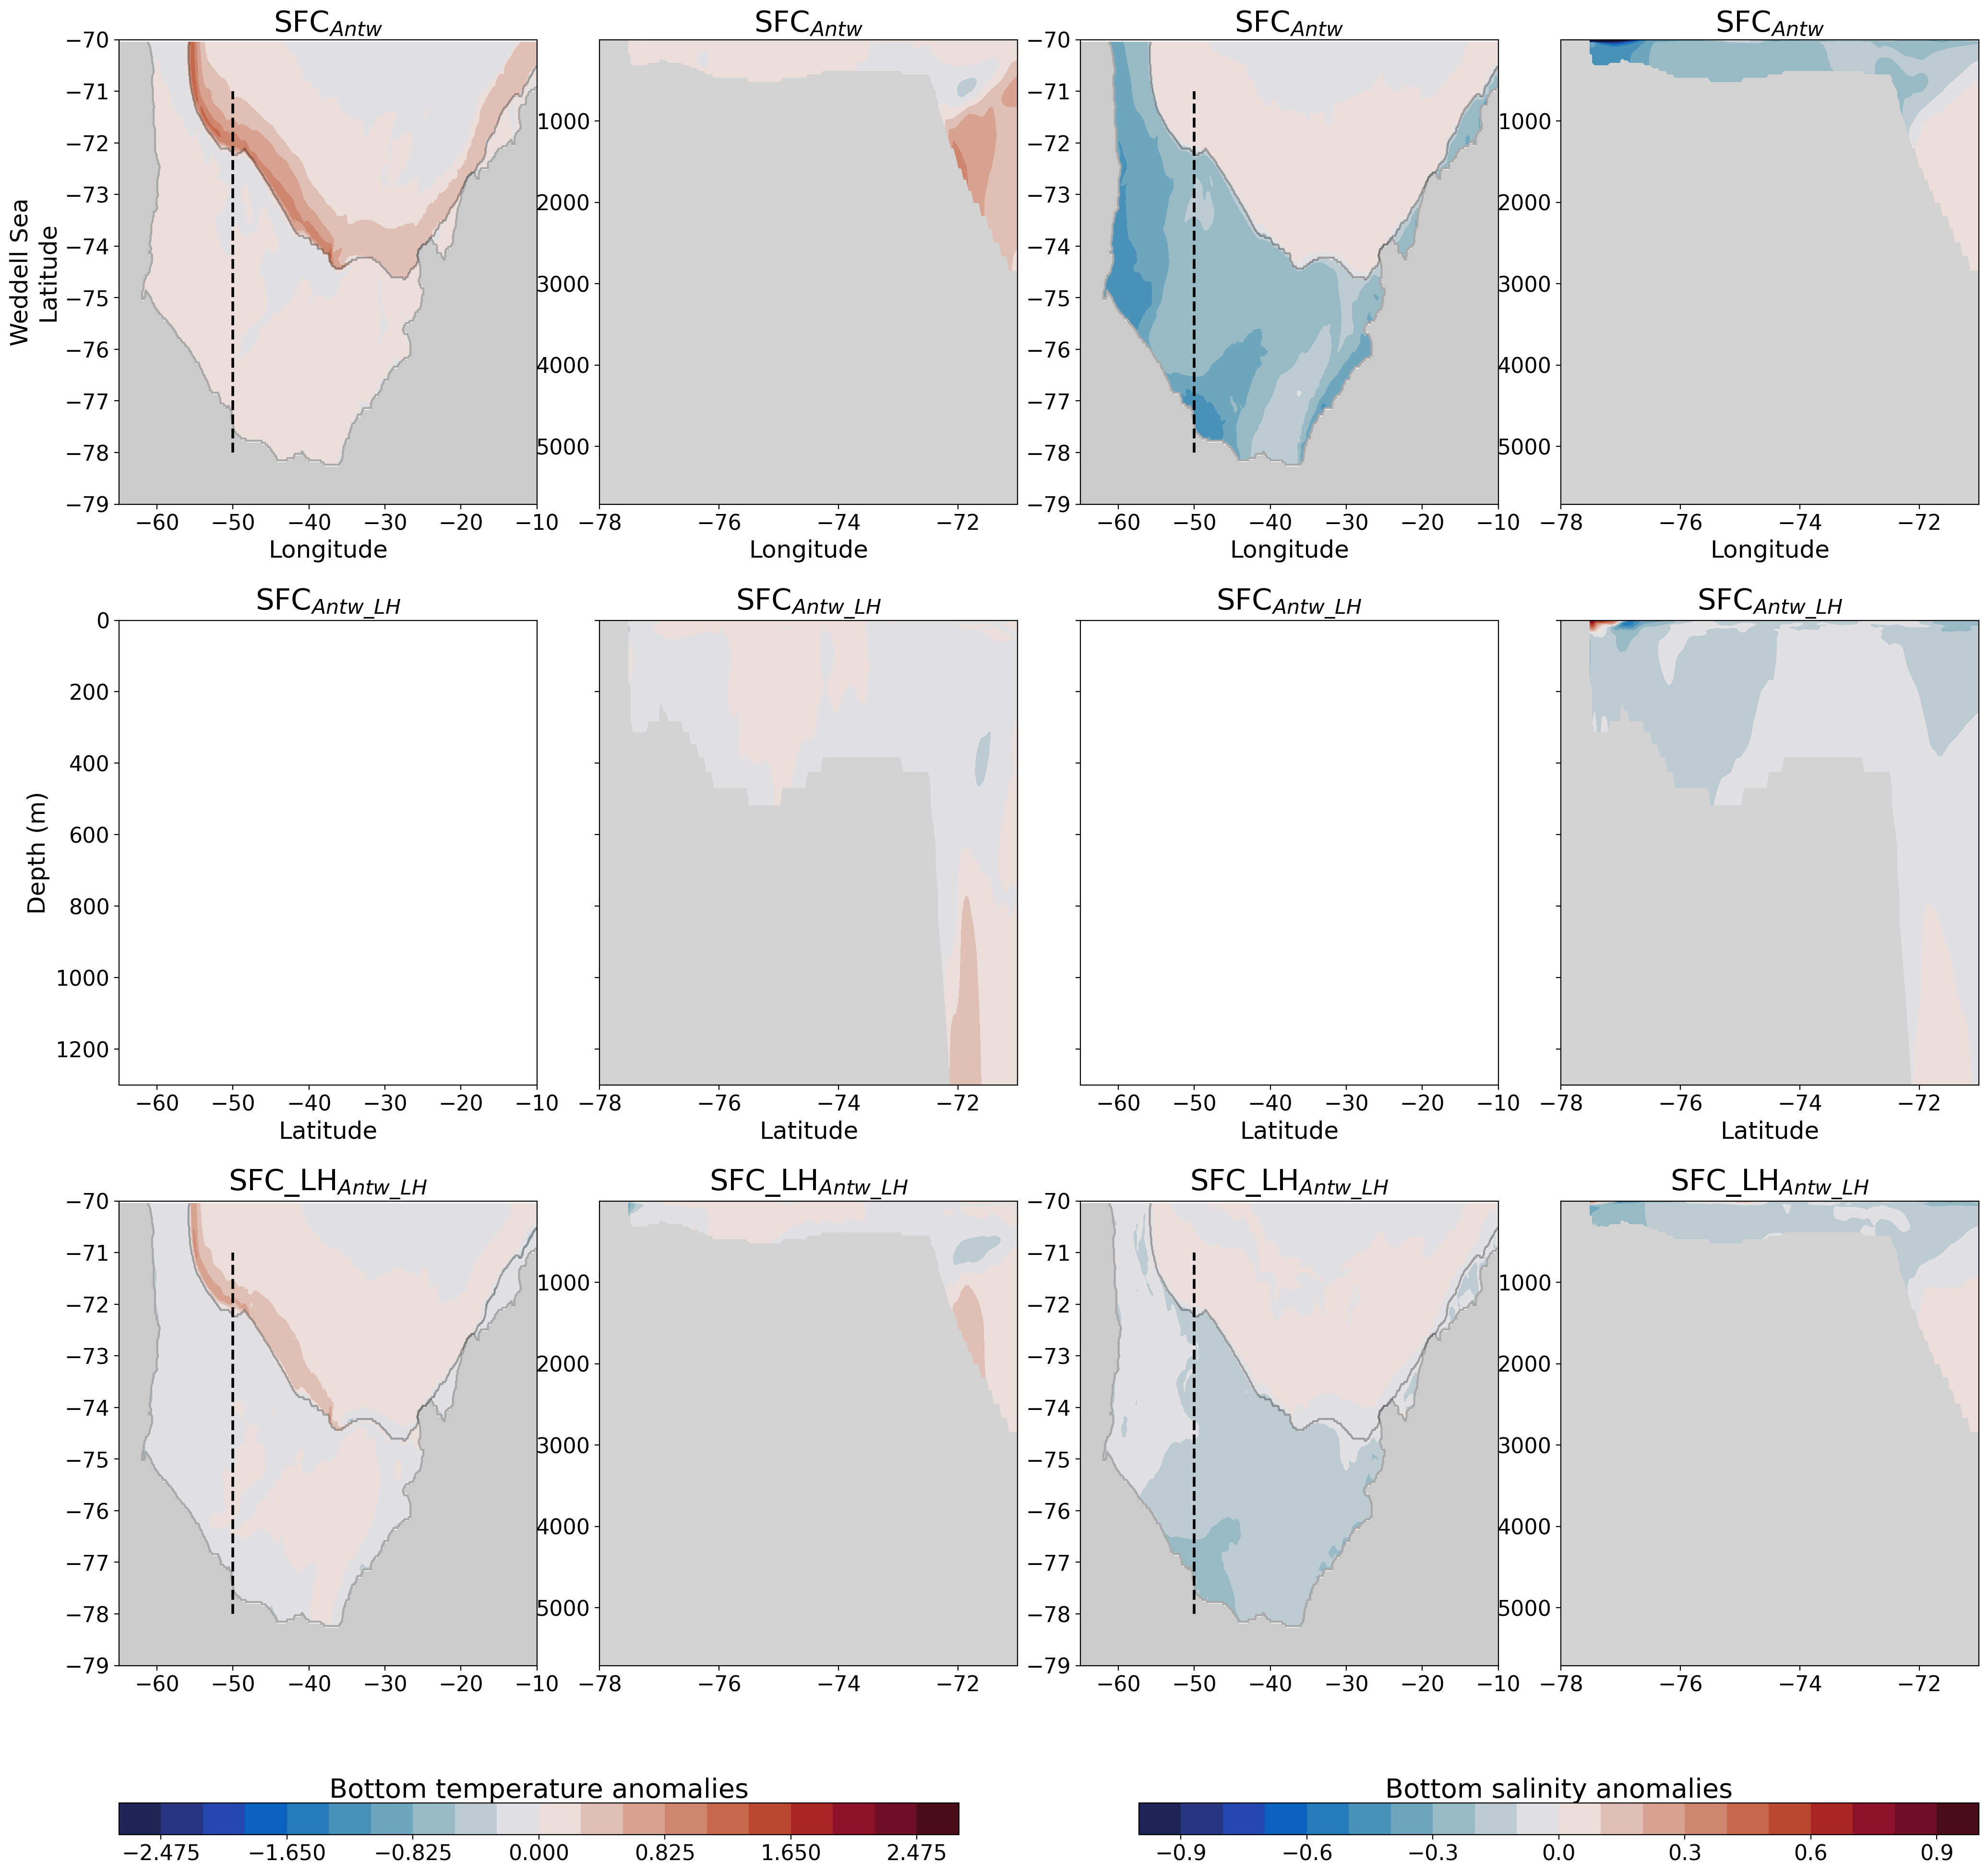

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 21.82 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 17.48 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/cli

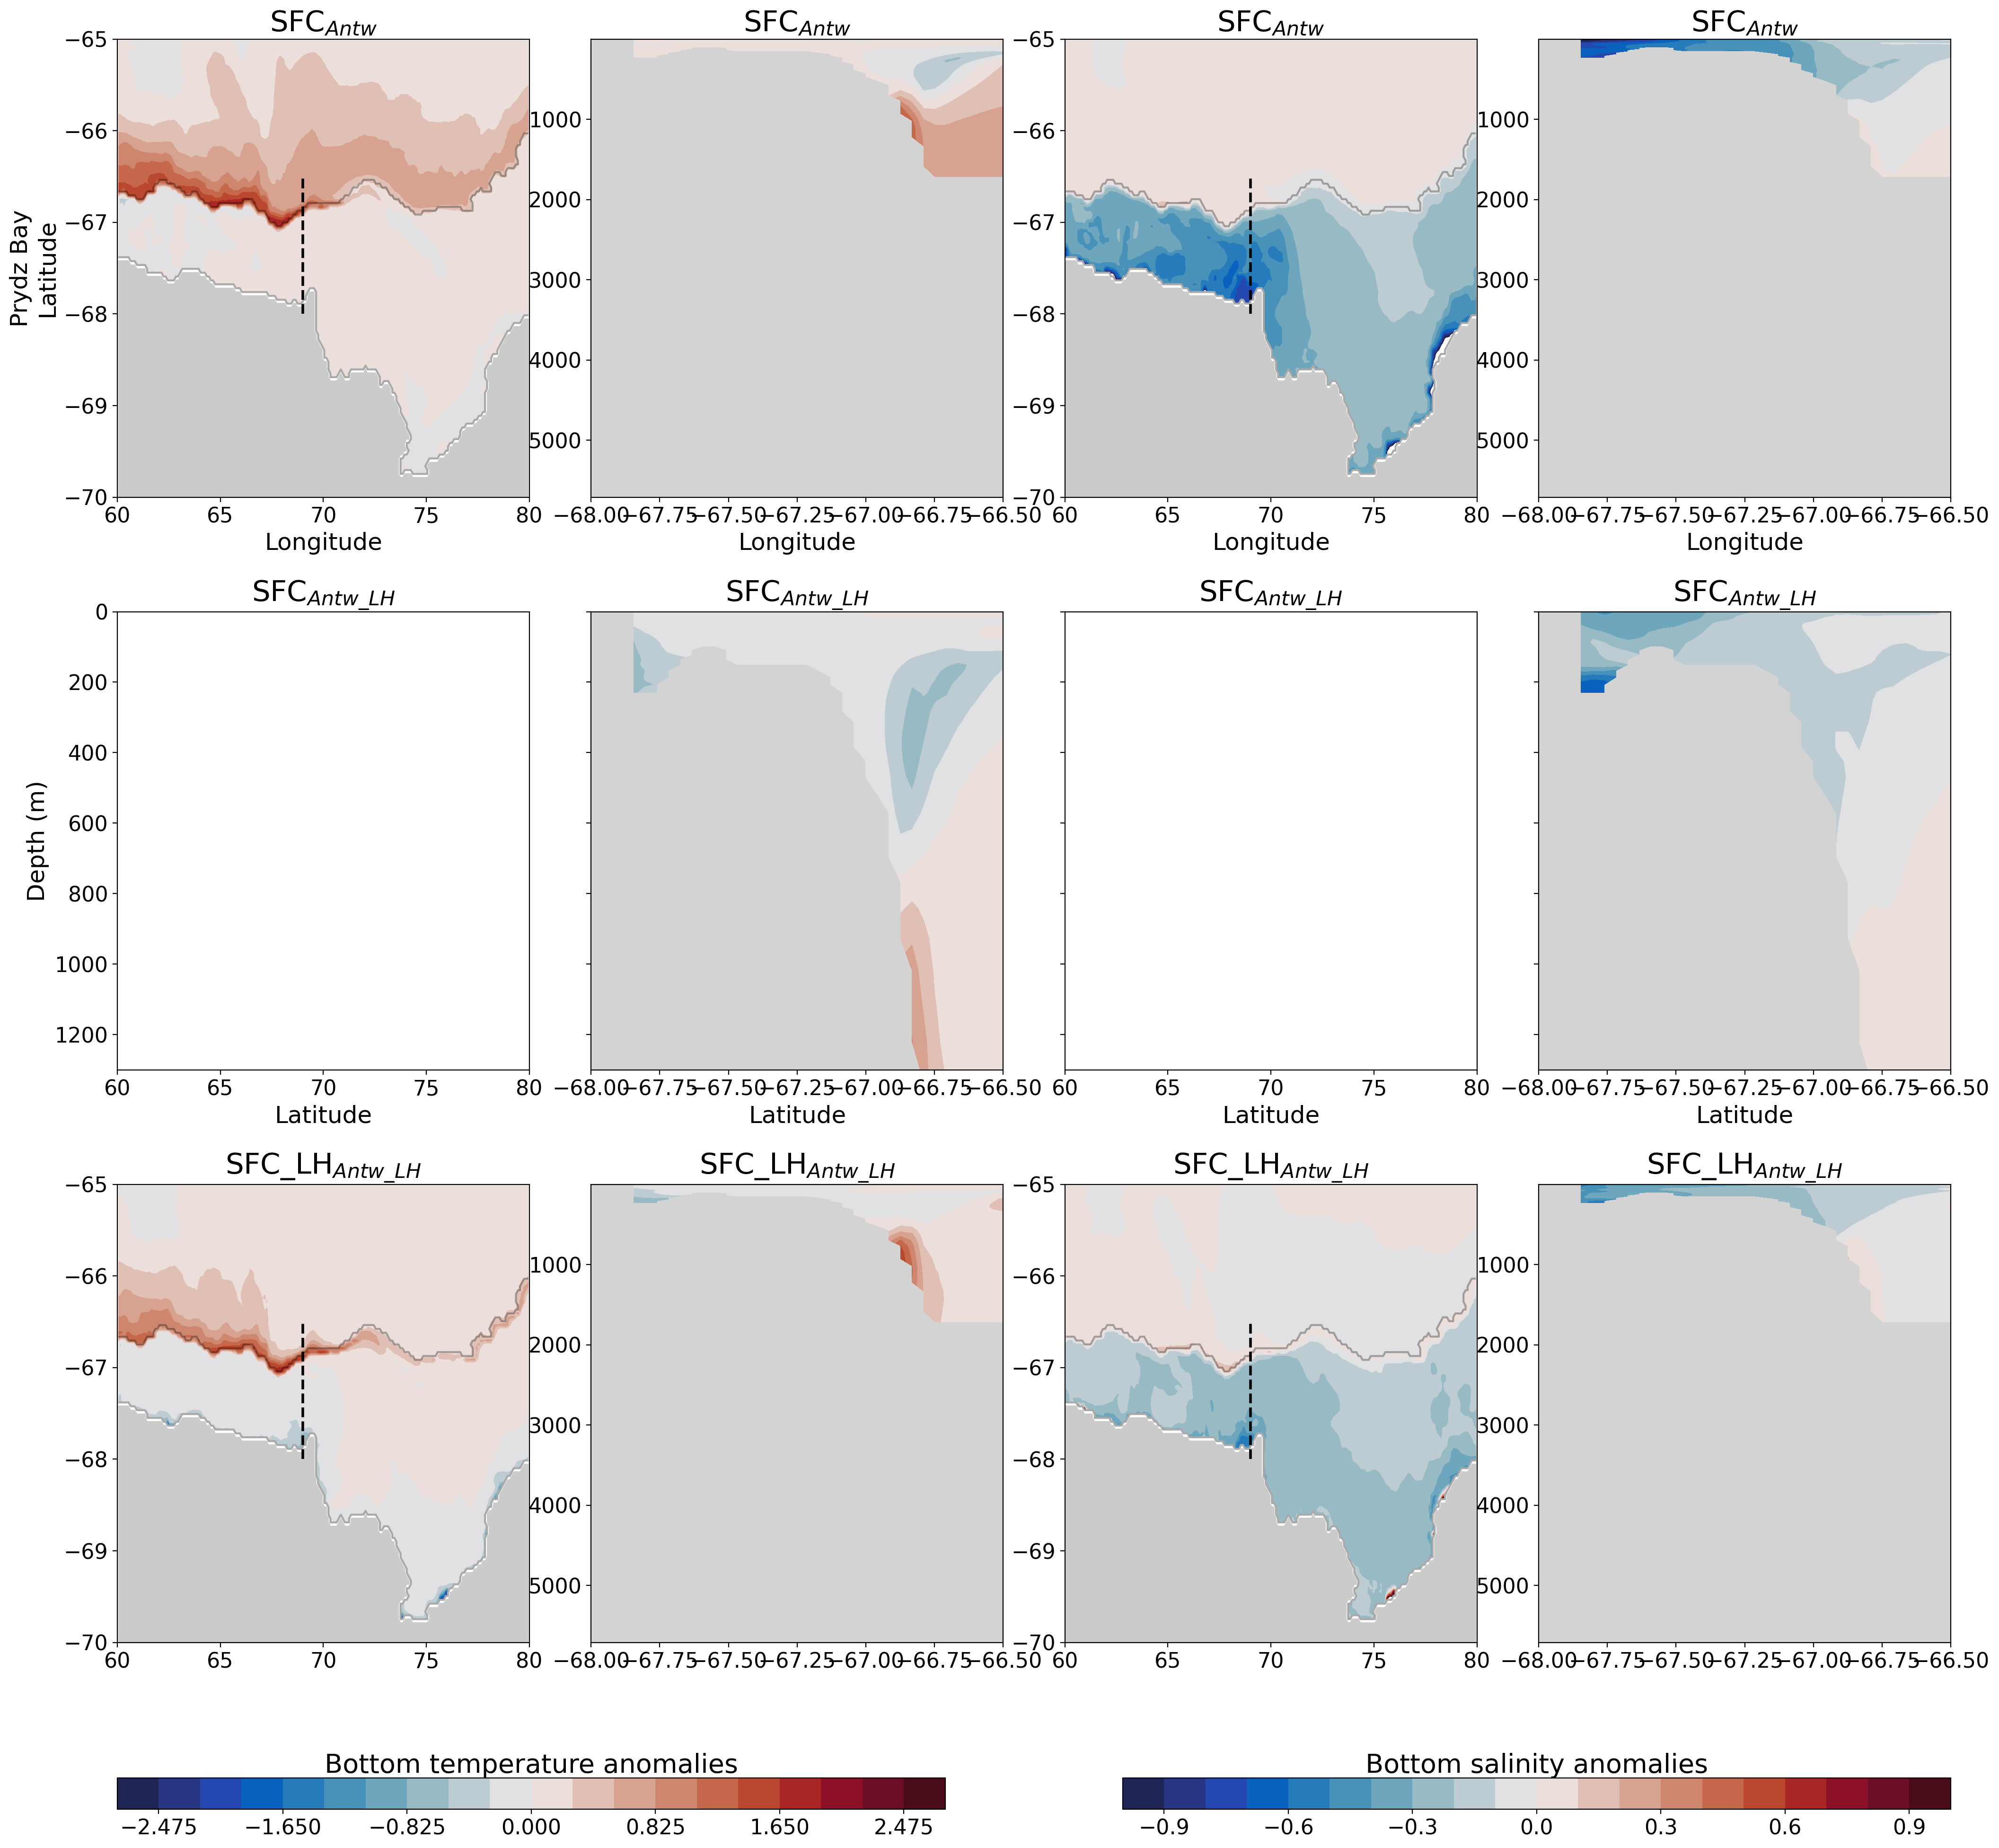

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 21.82 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 17.48 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/cli

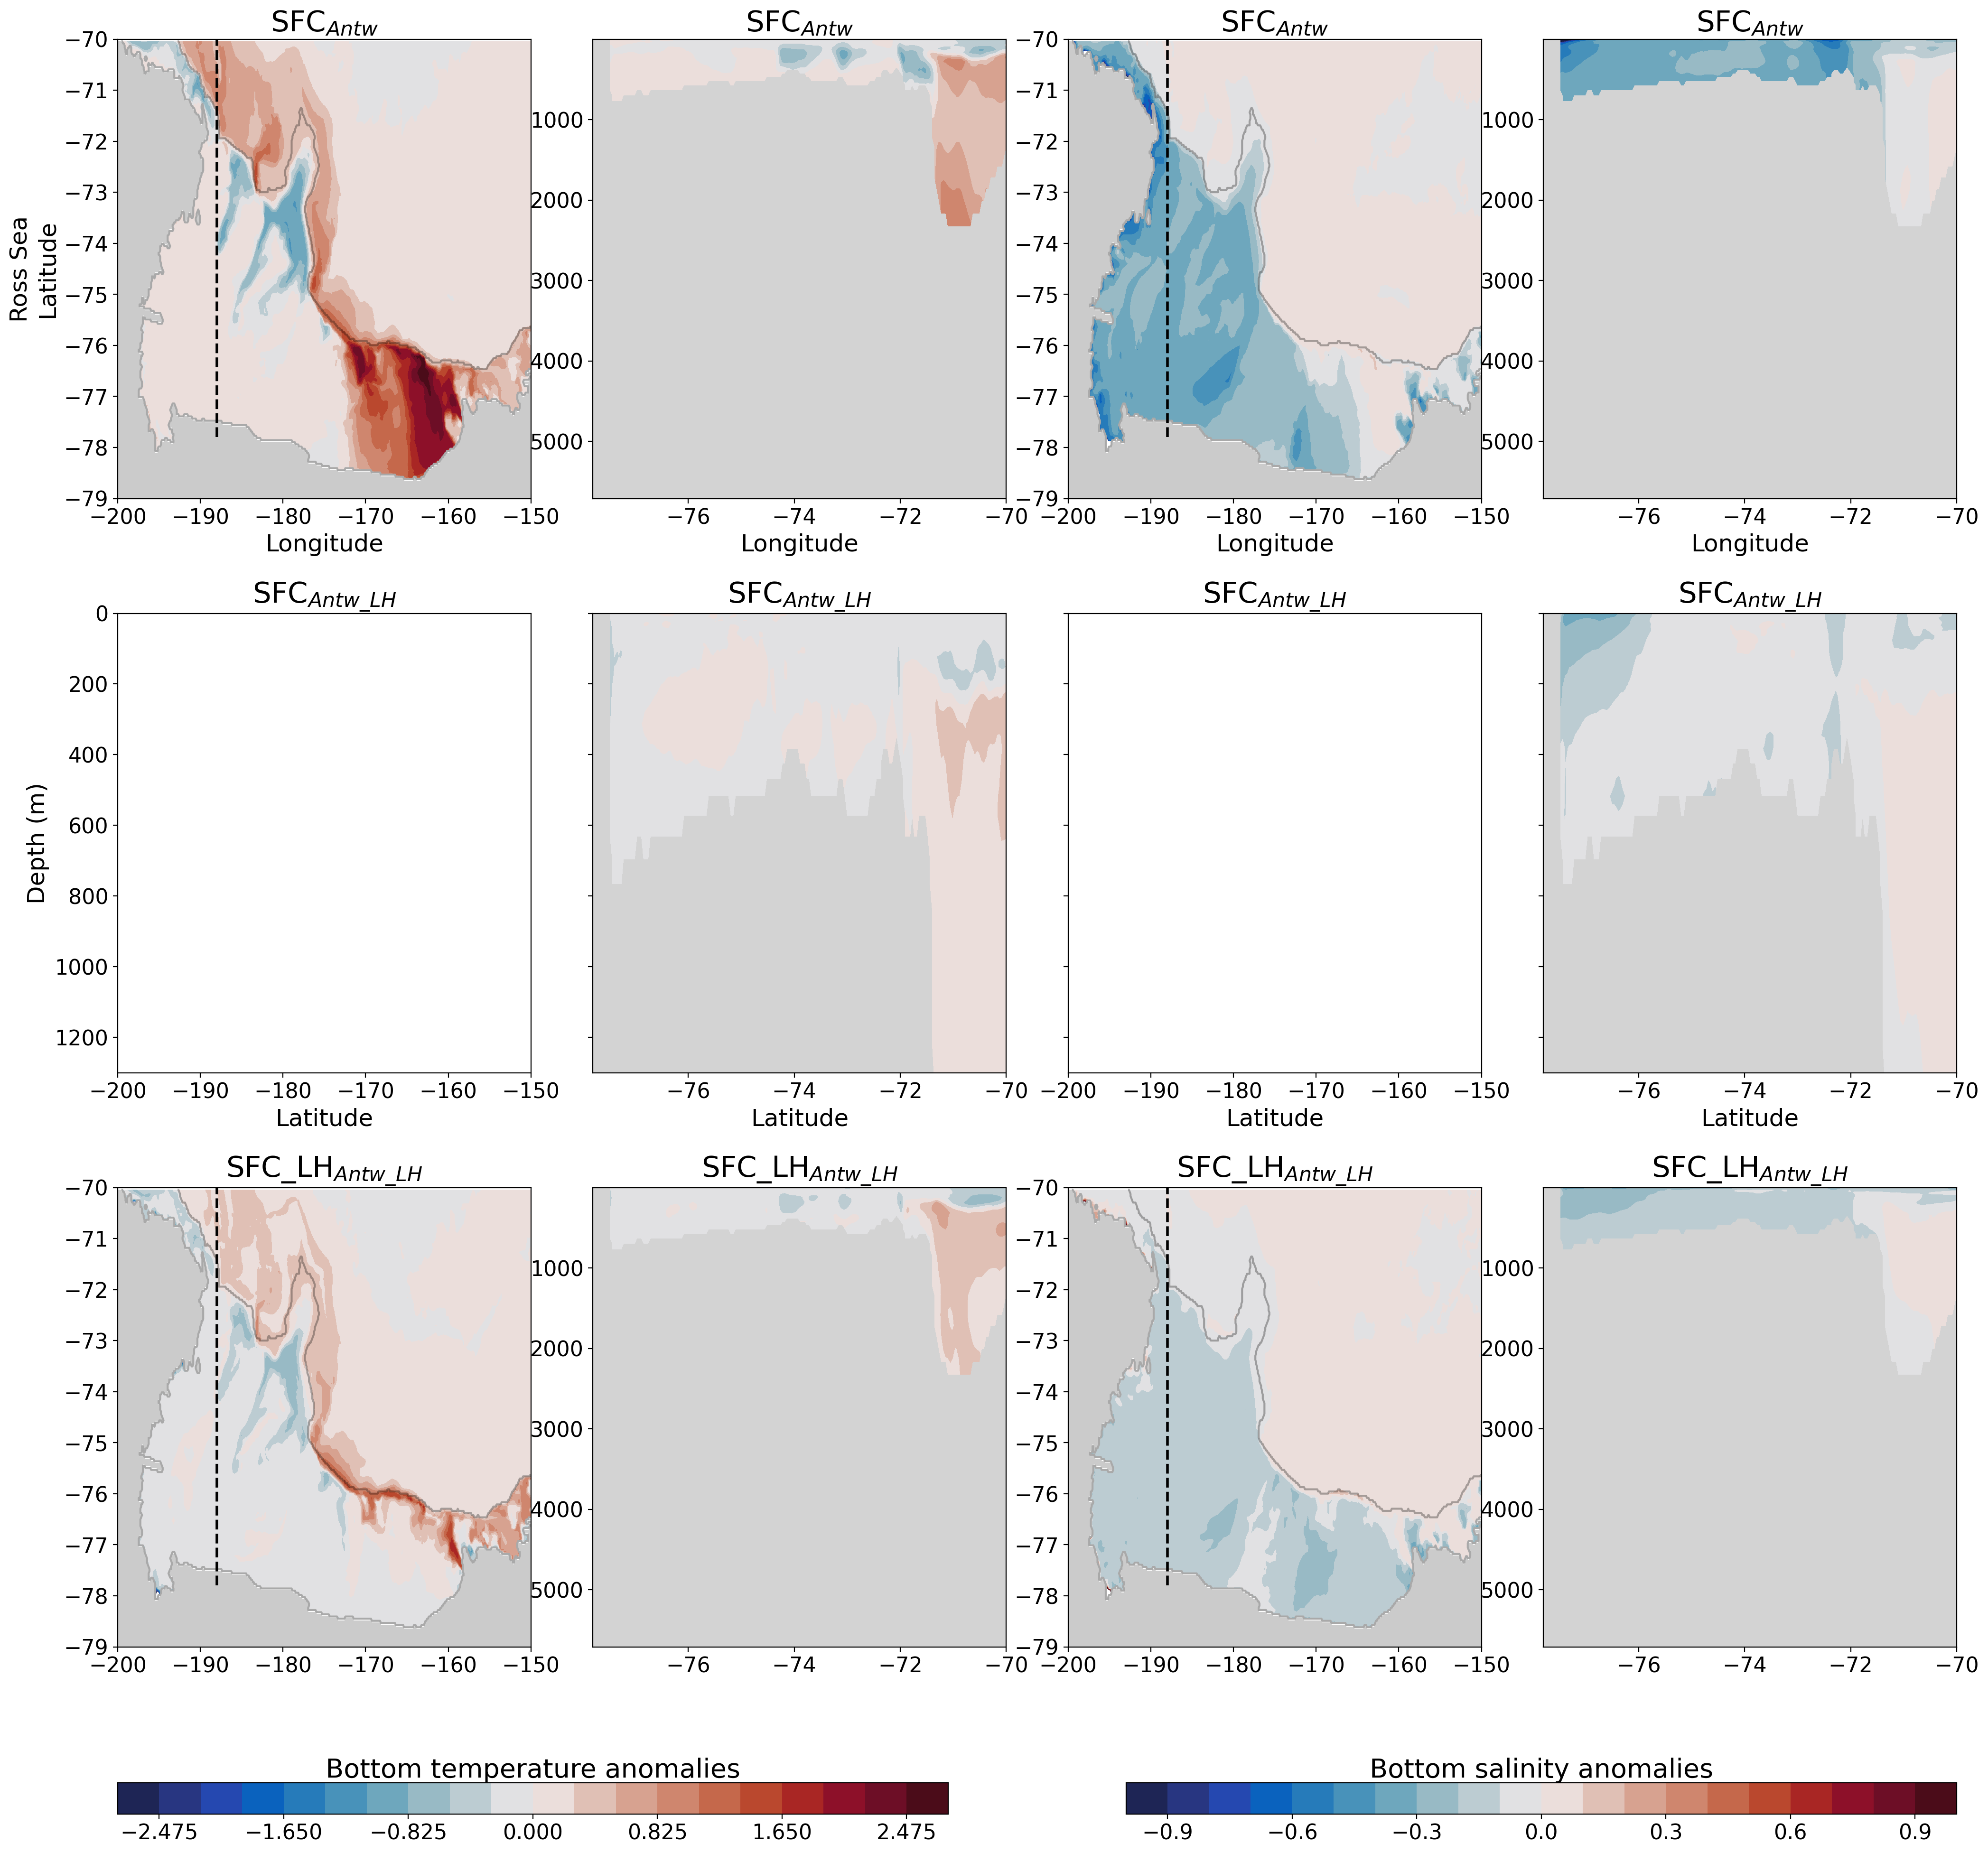

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 21.82 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 17.48 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/cli

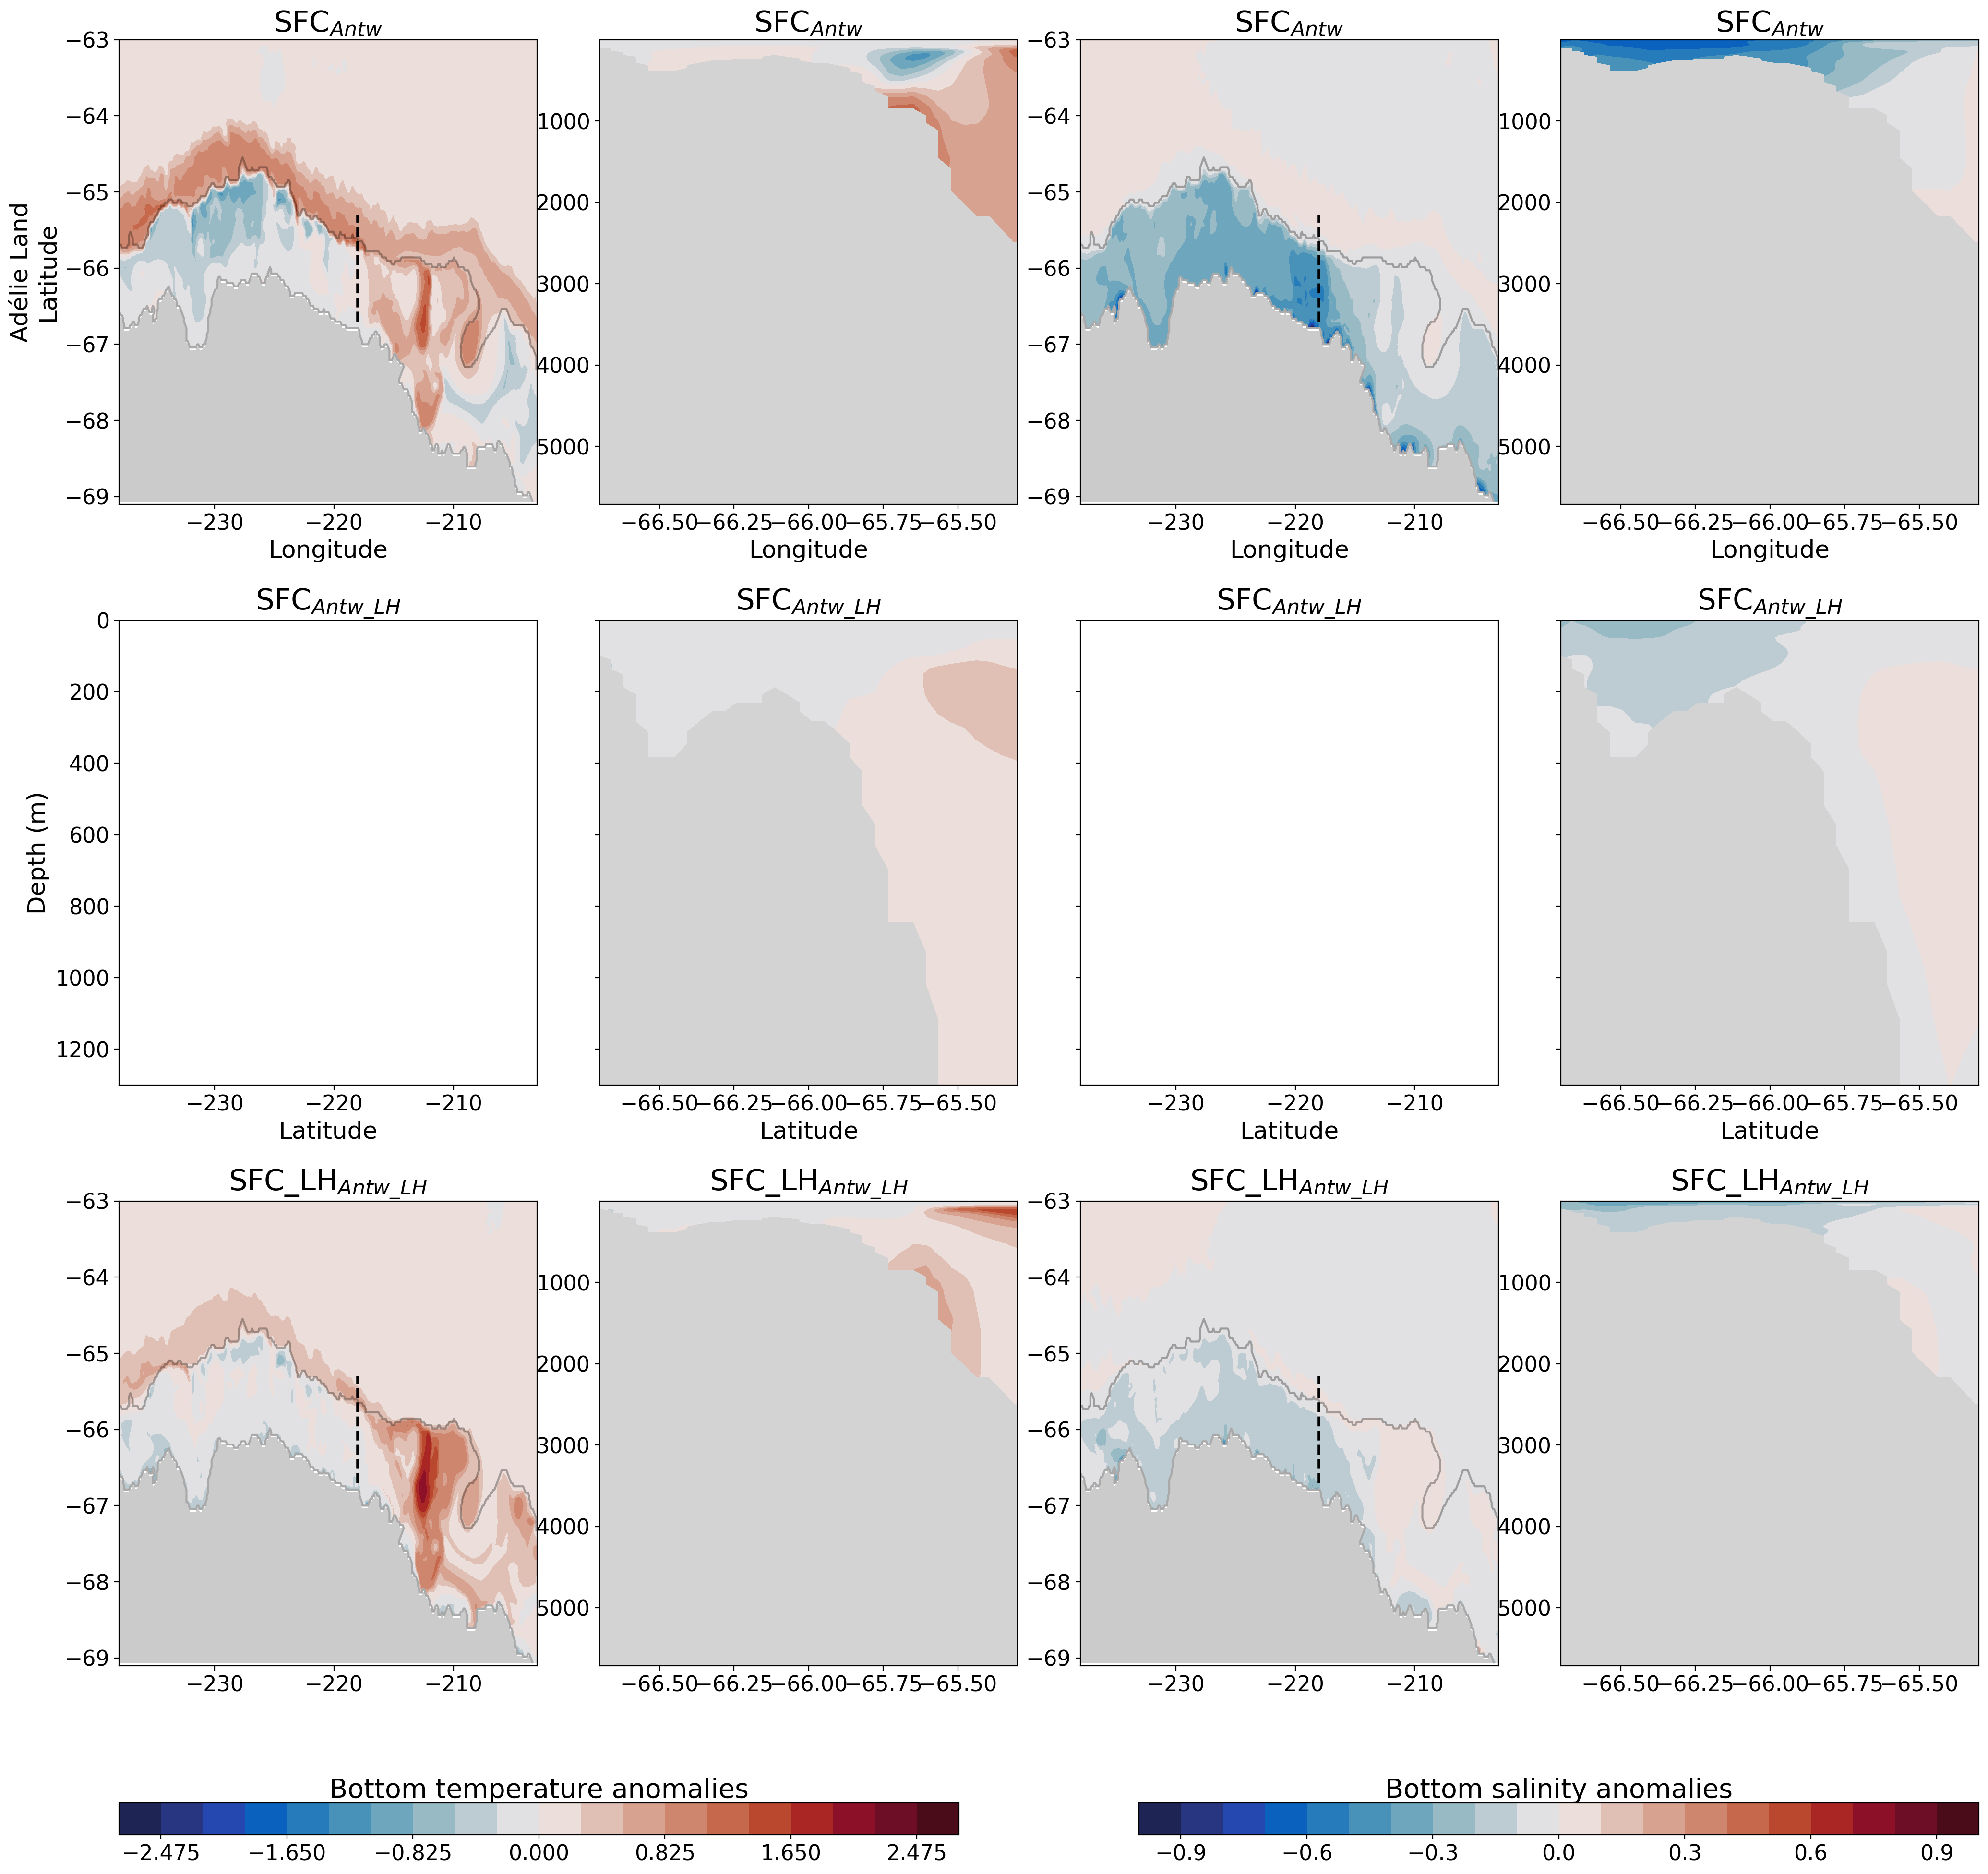

In [50]:
# ---------------------------------------------------------
# Loop through regions -> one figure per region
# ---------------------------------------------------------
for region, lims in regions.items():
    
    # define points with location of density profiles:
    lon_pt = profile_lons[region]
    lat_pt = profile_lats[region]
    
    # Create a figure with 1 row and 4 columns
    fig, ax = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(25,22),
    gridspec_kw={'height_ratios':[1,1,1]})
    
    plt.subplots_adjust(hspace=0.25, wspace=0.15)

    # =====================================================
    # Temperature A
    # =====================================================
    dataA = Atemp.sel(
        yt_ocean=slice(lims["ylim"][0], lims["ylim"][1])
    )

    lon = transect_lons[region]

    m_temp = plot_panel(
        ax[0,0],
        dataA,
        r'SFC$_{Antw}$',
        lims["xlim"],
        lims["ylim"],
        vmin=-2.75,
        vmax=2.75,
        cmap=cmo.cm.balance,
        transect_lon=lon,
        transect_latlim=lims["transect_latlim"],
        lon_point=lon_pt,
        lat_point=lat_pt
    )

    lat = section_coords[region]["lat"]
    z   = section_coords[region]["z"]
    
    m_temp_sec = plot_section(
        ax[0,1],
        lat,
        z,
        temp_cross[region]["A"],
        r'SFC$_{Antw}$',
        vmin=-2.75,
        vmax=2.75,
        cmap=cmo.cm.balance,
        xlim=lims["transect_latlim"]
    )

    # =====================================================
    # Temperature B
    # =====================================================
    dataB = Btemp.sel(
        yt_ocean=slice(lims["ylim"][0], lims["ylim"][1])
    )

    plot_panel(
        ax[1,0],
        dataB,
        r'SFC$_{Antw\_LH}$',
        lims["xlim"],
        lims["ylim"],
        vmin=-2.75,
        vmax=2.75,
        cmap=cmo.cm.balance,
        transect_lon=lon,
        transect_latlim=lims["transect_latlim"],
        lon_point=lon_pt,
        lat_point=lat_pt
    )

    plot_section(
        ax[1,1],
        lat,
        z,
        temp_cross[region]["B"],
        r'SFC$_{Antw\_LH}$',
        vmin=-2.75,
        vmax=2.75,
        cmap=cmo.cm.balance,
        xlim=lims["transect_latlim"]
    )

    # =====================================================
    # Temperature C
    # =====================================================
    dataC = Ctemp.sel(
        yt_ocean=slice(lims["ylim"][0], lims["ylim"][1])
    )

    plot_panel(
        ax[2,0],
        dataC,
        r'SFC_LH$_{Antw\_LH}$',
        lims["xlim"],
        lims["ylim"],
        vmin=-2.75,
        vmax=2.75,
        cmap=cmo.cm.balance,
        transect_lon=lon,
        transect_latlim=lims["transect_latlim"],
        lon_point=lon_pt,
        lat_point=lat_pt
    )

    plot_section(
        ax[2,1],
        lat,
        z,
        temp_cross[region]["C"],
        r'SFC_LH$_{Antw\_LH}$',
        vmin=-2.75,
        vmax=2.75,
        cmap=cmo.cm.balance,
        xlim=lims["transect_latlim"]
    )


    # =====================================================
    # Salinity A
    # =====================================================
    dataA = Asalt.sel(
        yt_ocean=slice(lims["ylim"][0], lims["ylim"][1])
    )

    m_salt = plot_panel(
        ax[0,2],
        dataA,
        r'SFC$_{Antw}$',
        lims["xlim"],
        lims["ylim"],
        vmin=-1,
        vmax=1,
        cmap=cmo.cm.balance,
        transect_lon=lon,
        transect_latlim=lims["transect_latlim"],
        lon_point=lon_pt,
        lat_point=lat_pt
    )

    m_salt_sec = plot_section(
        ax[0,3],
        lat,
        z,
        salt_cross[region]["A"],
        r'SFC$_{Antw}$',
        vmin=-1,
        vmax=1,
        cmap=cmo.cm.balance,
        xlim=lims["transect_latlim"]
    )

    # =====================================================
    # Salinity B
    # =====================================================
    dataB = Bsalt.sel(
        yt_ocean=slice(lims["ylim"][0], lims["ylim"][1])
    )

    plot_panel(
        ax[1,2],
        dataB,
        r'SFC$_{Antw\_LH}$',
        lims["xlim"],
        lims["ylim"],
        vmin=-1,
        vmax=1,
        cmap=cmo.cm.balance,
        transect_lon=lon,
        transect_latlim=lims["transect_latlim"],
        lon_point=lon_pt,
        lat_point=lat_pt
    )

    plot_section(
        ax[1,3],
        lat,
        z,
        salt_cross[region]["B"],
        r'SFC$_{Antw\_LH}$',
        vmin=-1,
        vmax=1,
        cmap=cmo.cm.balance,
        xlim=lims["transect_latlim"]
    )

    # =====================================================
    # Salinity C
    # =====================================================
    dataC = Csalt.sel(
        yt_ocean=slice(lims["ylim"][0], lims["ylim"][1])
    )

    plot_panel(
        ax[2,2],
        dataC,
        r'SFC_LH$_{Antw\_LH}$',
        lims["xlim"],
        lims["ylim"],
        vmin=-1,
        vmax=1,
        cmap=cmo.cm.balance,
        transect_lon=lon,
        transect_latlim=lims["transect_latlim"],
        lon_point=lon_pt,
        lat_point=lat_pt
    )

    plot_section(
        ax[2,3],
        lat,
        z,
        salt_cross[region]["C"],
        r'SFC_LH$_{Antw\_LH}$',
        vmin=-1,
        vmax=1,
        cmap=cmo.cm.balance,
        xlim=lims["transect_latlim"]
    )
    
    
    # -----------------------------------------------------
    # Labels
    # -----------------------------------------------------
    ax[0,0].set_ylabel(f'{region}\nLatitude', fontsize=18)
    for xx in range(4):
        ax[0,xx].set_xlabel('Longitude', fontsize=18)

    ax[1,0].set_ylabel('Depth (m)', fontsize=18)

    for xx in range(4):
        ax[1,xx].set_xlabel('Latitude', fontsize=18)

    # ------------------------------------------------------
    # Depth limit for transects:
    # ------------------------------------------------------
    for xx in range(4):
        ax[1,xx].set_ylim(1300, 0)    # upper 1300 m only
    for xx in range(1,4):
        ax[1,xx].set_yticklabels([])

    # -----------------------------------------------------
    # Colorbars
    # -----------------------------------------------------
    cax_temp = fig.add_axes([0.125, 0.03, 0.35, 0.015])
    cbar_temp = plt.colorbar(
        m_temp,
        cax=cax_temp,
        orientation='horizontal',
        extend='both'
    )
    cbar_temp.ax.xaxis.set_label_position('top')
    cbar_temp.set_label(
        'Bottom temperature anomalies',
        fontsize=20
    )

    cax_salt = fig.add_axes([0.55, 0.03, 0.35, 0.015])
    cbar_salt = plt.colorbar(
        m_salt,
        cax=cax_salt,
        orientation='horizontal',
        extend='both'
    )
    cbar_salt.ax.xaxis.set_label_position('top')
    cbar_salt.set_label(
        'Bottom salinity anomalies',
        fontsize=20
    )

    cbar_temp.ax.tick_params(labelsize=16)
    cbar_salt.ax.tick_params(labelsize=16)

    # -----------------------------------------------------
    # Save
    # -----------------------------------------------------
    plt.savefig(
        f"{figdir}{region}_TSbot.png",
        bbox_inches='tight',
        dpi=300
    )

    plt.show()


### Vertical profiles of density per region: mean state vs Antwater

After the AARC2036 meeting, we agreed that the response of DSW seems to depend on the mean state. The idea is to add to Fig. 2 a row with density vertical profiles across experiments to see if the mean state is a major contributor to the DSW response. Does a more stratified initial state means that the DSW will shutdown easily?

In [30]:
# ============================================================
# Define temp/salt anomaly locations to be used for density profiles ---> using abs temp/salt
# ============================================================

# winter only:
# start_time='1919-07-01'
# end_time='1919-10-31'
# time_slice = slice(start_time,end_time)

profile_coords = {}
abs_temp_profile = {}
abs_salt_profile = {}

profile_lons = {
    "Weddell Sea": -50,
    "Prydz Bay": 69,
    "Ross Sea": -192, 
    "Adélie Land": -217,
}

profile_lats = {
    "Weddell Sea": -77.5,
    "Prydz Bay": -67.6,
    "Ross Sea": -73.6,
    "Adélie Land": -66.8,
}

for region, lon in profile_lons.items():
    lat = profile_lats[region]

    profile = (
    t1a.isel(time=-1)
       .sel(yt_ocean=lat, method='nearest')
       .sel(xt_ocean=lon, method='nearest')
    )

    profile_coords[region] = {
        "lon": float(profile.xt_ocean),
        "lat": profile.yt_ocean,
        "z": profile.st_ocean
    }


    abs_temp_profile[region] = {
        "A": t1.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').where((t1.time.dt.year.isin([1917, 1918, 1919])) & (t1.time.dt.month.isin([7, 8, 9, 10])), drop=True
        ).mean('time').temp,

        "B": t1b.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').where((t1.time.dt.year.isin([1917, 1918, 1919])) & (t1.time.dt.month.isin([7, 8, 9, 10])), drop=True
        ).mean('time').temp,

        "C": t3.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').where((t1.time.dt.year.isin([1917, 1918, 1919])) & (t1.time.dt.month.isin([7, 8, 9, 10])), drop=True
        ).mean('time').temp,

        "D": t1a.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').where((t1.time.dt.year.isin([1917, 1918, 1919])) & (t1.time.dt.month.isin([7, 8, 9, 10])), drop=True
        ).mean('time').temp,

        "E": t1a_c.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').where((t1.time.dt.year.isin([1917, 1918, 1919])) & (t1.time.dt.month.isin([7, 8, 9, 10])), drop=True
        ).mean('time').temp,

        "F": t1a_b.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').where((t1.time.dt.year.isin([1917, 1918, 1919])) & (t1.time.dt.month.isin([7, 8, 9, 10])), drop=True
        ).mean('time').temp,

        "G": t3a.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').where((t1.time.dt.year.isin([1917, 1918, 1919])) & (t1.time.dt.month.isin([7, 8, 9, 10])), drop=True
        ).mean('time').temp

        
    }

    abs_salt_profile[region] = {
        "A": s1.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').where((t1.time.dt.year.isin([1917, 1918, 1919])) & (t1.time.dt.month.isin([7, 8, 9, 10])), drop=True
        ).mean('time').salt,

        "B": s1b.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').where((t1.time.dt.year.isin([1917, 1918, 1919])) & (t1.time.dt.month.isin([7, 8, 9, 10])), drop=True
        ).mean('time').salt,

        "C": s3.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').where((t1.time.dt.year.isin([1917, 1918, 1919])) & (t1.time.dt.month.isin([7, 8, 9, 10])), drop=True
        ).mean('time').salt,

        "D": s1a.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').where((t1.time.dt.year.isin([1917, 1918, 1919])) & (t1.time.dt.month.isin([7, 8, 9, 10])), drop=True
        ).mean('time').salt,

        "E": s1a_c.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').where((t1.time.dt.year.isin([1917, 1918, 1919])) & (t1.time.dt.month.isin([7, 8, 9, 10])), drop=True
        ).mean('time').salt,

        "F": s1a_b.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').where((t1.time.dt.year.isin([1917, 1918, 1919])) & (t1.time.dt.month.isin([7, 8, 9, 10])), drop=True
        ).mean('time').salt,

        "G": s3a.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').where((t1.time.dt.year.isin([1917, 1918, 1919])) & (t1.time.dt.month.isin([7, 8, 9, 10])), drop=True
        ).mean('time').salt
    }



In [31]:
import gsw


def calc_rho_profile(temperature,salinity,lat_lim):
    # pressure from depth (depth positive downward)
    p = gsw.p_from_z(-temperature.st_ocean, lat_lim)  # approximate latitude

    rho = xr.apply_ufunc(
        gsw.rho,
        salinity,                      # Absolute Salinity ideally
        temperature,                      # Conservative Temperature ideally
        p*0,
        dask='allowed'
    )

    rho.name = 'density'
    
    # mask per latitude:
    # shelf_mask = rho.yt_ocean < lat_lim
    
    # rho_shelf = rho.where(shelf_mask)
    # rho_profile = rho_shelf.mean('yt_ocean') - 1000
    rho_profile = rho - 1000

    return rho_profile




/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 32.74 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.46 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/cli

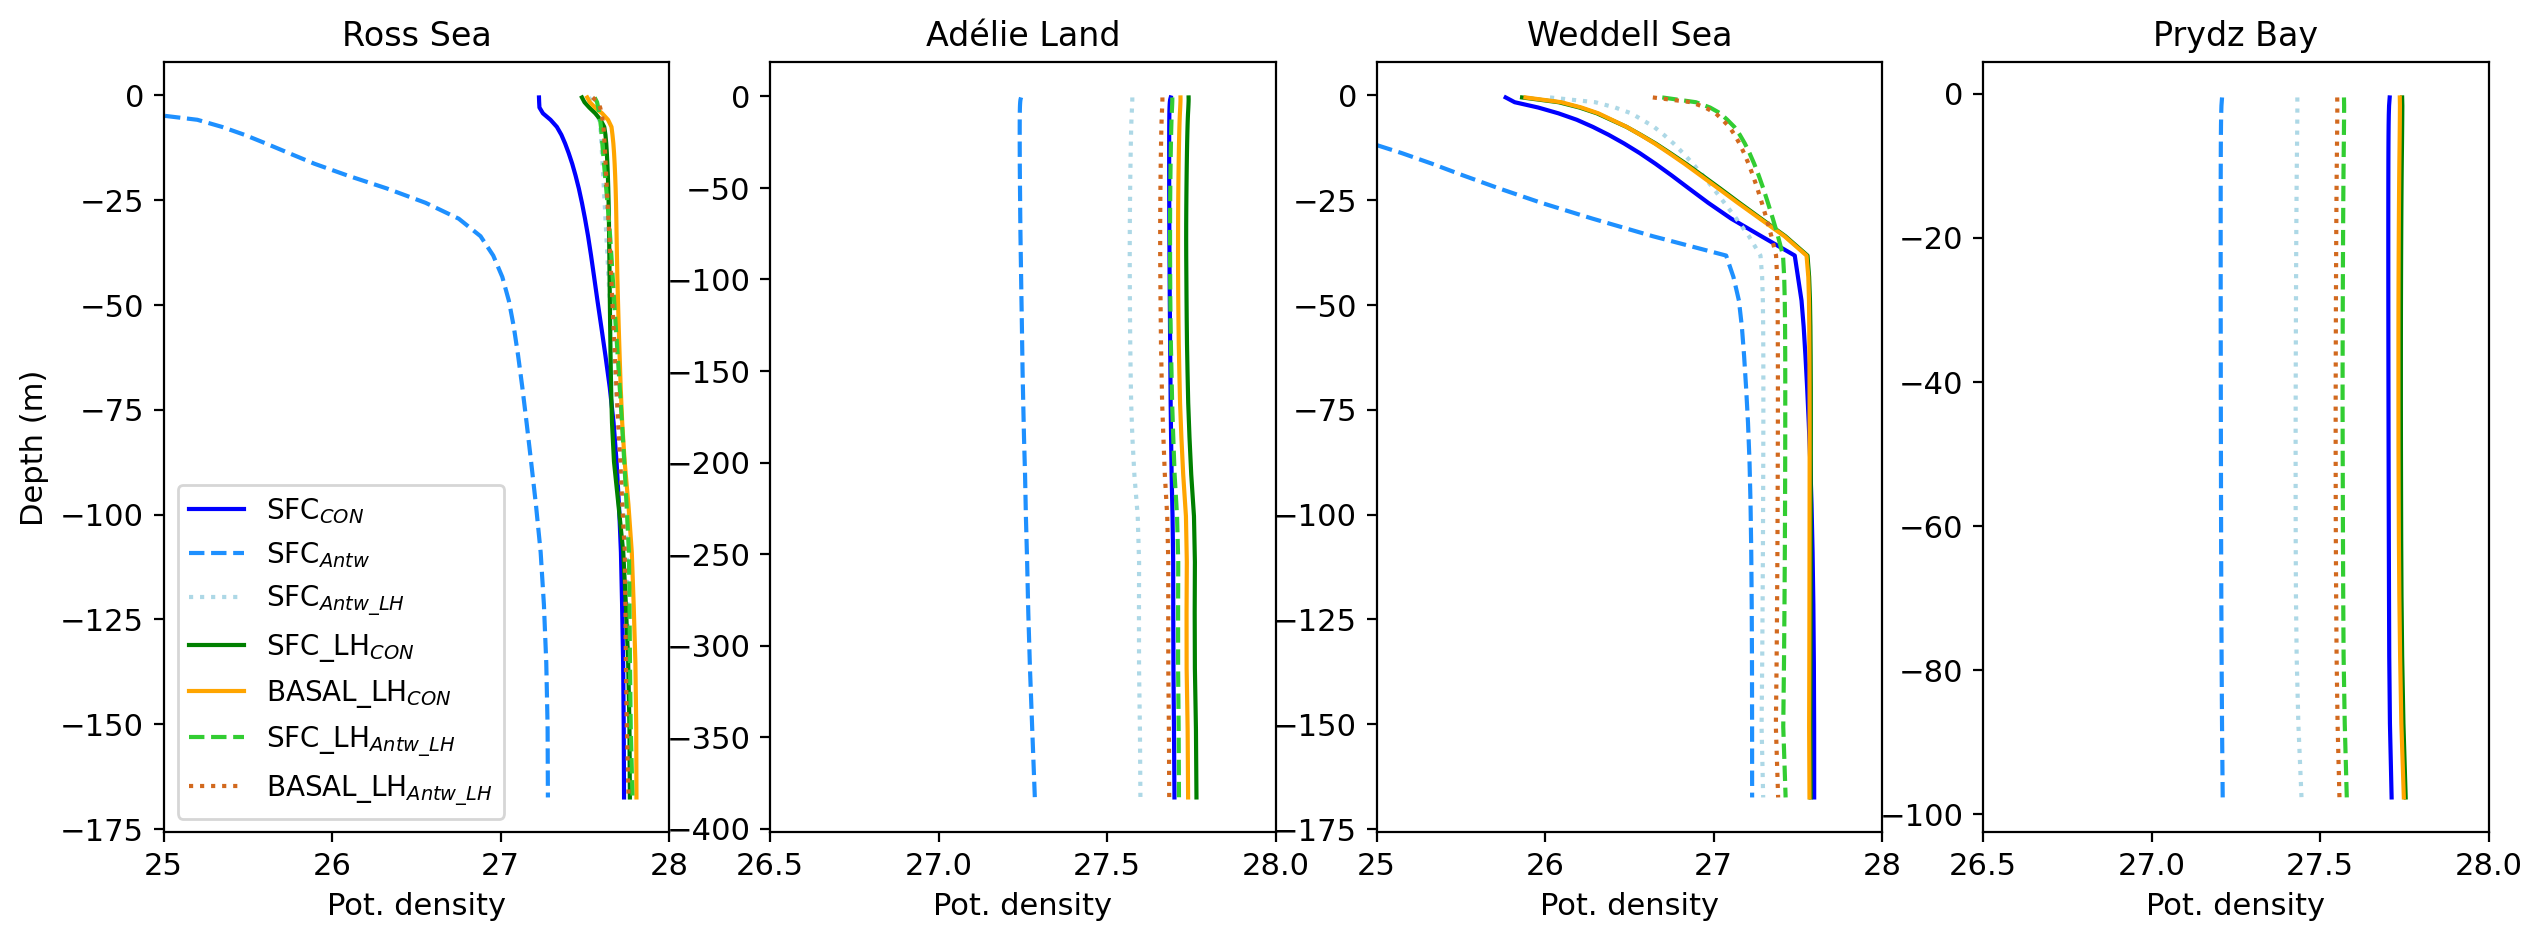

In [32]:
latlim = -77 # for Ross Sea

temp = abs_temp_profile['Ross Sea']['A'] - 273.15
salt = abs_salt_profile['Ross Sea']['A']
rhoA_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['B'] - 273.15
salt = abs_salt_profile['Ross Sea']['B']
rhoB_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['C'] - 273.15
salt = abs_salt_profile['Ross Sea']['C']
rhoC_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['D'] - 273.15
salt = abs_salt_profile['Ross Sea']['D']
rhoD_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['E'] - 273.15
salt = abs_salt_profile['Ross Sea']['E']
rhoE_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['F'] - 273.15
salt = abs_salt_profile['Ross Sea']['F']
rhoF_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['G'] - 273.15
salt = abs_salt_profile['Ross Sea']['G']
rhoG_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

fig, ax = plt.subplots(1,4, figsize=(15,5))

ax[0].set_title('Ross Sea')
ax[0].plot(rhoA_profile,-rhoA_profile.st_ocean,color='blue',linestyle='-',label='SFC$_{CON}$')
ax[0].plot(rhoD_profile,-rhoD_profile.st_ocean,color='dodgerblue',linestyle='--',label='SFC$_{Antw}$') 
ax[0].plot(rhoE_profile,-rhoE_profile.st_ocean,color='lightblue',linestyle=':',label='SFC$_{Antw\_LH}$')
ax[0].plot(rhoB_profile,-rhoB_profile.st_ocean,color='green',linestyle='-',label='SFC_LH$_{CON}$')
ax[0].plot(rhoC_profile,-rhoC_profile.st_ocean,color='orange',linestyle='-',label='BASAL_LH$_{CON}$')
ax[0].plot(rhoF_profile,-rhoF_profile.st_ocean,color='limegreen',linestyle='--',label='SFC_LH$_{Antw\_LH}$')
ax[0].plot(rhoG_profile,-rhoG_profile.st_ocean,color='chocolate',linestyle=':',label='BASAL_LH$_{Antw\_LH}$')
ax[0].legend(loc='lower left')
ax[0].set_xlim(25.5,28)

## Weddell ---------------------------------------
latlim = -77 # for Weddell Sea

temp = abs_temp_profile['Weddell Sea']['A'] - 273.15
salt = abs_salt_profile['Weddell Sea']['A']
rhoA_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['B'] - 273.15
salt = abs_salt_profile['Weddell Sea']['B']
rhoB_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['C'] - 273.15
salt = abs_salt_profile['Weddell Sea']['C']
rhoC_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['D'] - 273.15
salt = abs_salt_profile['Weddell Sea']['D']
rhoD_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['E'] - 273.15
salt = abs_salt_profile['Weddell Sea']['E']
rhoE_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['F'] - 273.15
salt = abs_salt_profile['Weddell Sea']['F']
rhoF_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['G'] - 273.15
salt = abs_salt_profile['Weddell Sea']['G']
rhoG_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

ax[2].set_title('Weddell Sea')

ax[2].plot(rhoA_profile,-rhoA_profile.st_ocean,color='blue',linestyle='-',label='SFC$_{CON}$')
ax[2].plot(rhoD_profile,-rhoD_profile.st_ocean,color='dodgerblue',linestyle='--',label='SFC_LH$_{CON}$')
ax[2].plot(rhoE_profile,-rhoE_profile.st_ocean,color='lightblue',linestyle=':',label='BASAL_LH$_{CON}$')
ax[2].plot(rhoB_profile,-rhoB_profile.st_ocean,color='green',linestyle='-',label='SFC$_{Antw}$')
ax[2].plot(rhoC_profile,-rhoB_profile.st_ocean,color='orange',linestyle='-',label='SFC$_{Antw\_LH}$')
ax[2].plot(rhoF_profile,-rhoB_profile.st_ocean,color='limegreen',linestyle='--',label='SFC_LH$_{Antw\_LH}$')
ax[2].plot(rhoG_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle=':',label='BASAL_LH$_{Antw\_LH}$')
ax[2].set_xlim(25.,27.7)

## Adèlie ---------------------------------------
latlim = -66.3 # for Adélie Land

temp = abs_temp_profile['Adélie Land']['A'] - 273.15
salt = abs_salt_profile['Adélie Land']['A']
rhoA_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['B'] - 273.15
salt = abs_salt_profile['Adélie Land']['B']
rhoB_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['C'] - 273.15
salt = abs_salt_profile['Adélie Land']['C']
rhoC_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['D'] - 273.15
salt = abs_salt_profile['Adélie Land']['D']
rhoD_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['E'] - 273.15
salt = abs_salt_profile['Adélie Land']['E']
rhoE_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['F'] - 273.15
salt = abs_salt_profile['Adélie Land']['F']
rhoF_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['G'] - 273.15
salt = abs_salt_profile['Adélie Land']['G']
rhoG_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

ax[1].set_title('Adélie Land')

ax[1].plot(rhoA_profile,-rhoA_profile.st_ocean,color='blue',linestyle='-',label='SFC$_{CON}$')
ax[1].plot(rhoD_profile,-rhoD_profile.st_ocean,color='dodgerblue',linestyle='--',label='SFC_LH$_{CON}$')
ax[1].plot(rhoE_profile,-rhoE_profile.st_ocean,color='lightblue',linestyle=':',label='BASAL_LH$_{CON}$')

ax[1].plot(rhoB_profile,-rhoB_profile.st_ocean,color='green',linestyle='-',label='SFC$_{Antw}$')
ax[1].plot(rhoC_profile,-rhoB_profile.st_ocean,color='orange',linestyle='-',label='SFC$_{Antw\_LH}$')
ax[1].plot(rhoF_profile,-rhoB_profile.st_ocean,color='limegreen',linestyle='--',label='SFC_LH$_{Antw\_LH}$')
ax[1].plot(rhoG_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle=':',label='BASAL_LH$_{Antw\_LH}$')
ax[1].set_xlim(27.,28)

## Adelie ---------------------------------------
latlim = -67.5 # for Prydz Bay

temp = abs_temp_profile['Prydz Bay']['A'] - 273.15
salt = abs_salt_profile['Prydz Bay']['A']
rhoA_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['B'] - 273.15
salt = abs_salt_profile['Prydz Bay']['B']
rhoB_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['C'] - 273.15
salt = abs_salt_profile['Prydz Bay']['C']
rhoC_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['D'] - 273.15
salt = abs_salt_profile['Prydz Bay']['D']
rhoD_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['E'] - 273.15
salt = abs_salt_profile['Prydz Bay']['E']
rhoE_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['F'] - 273.15
salt = abs_salt_profile['Prydz Bay']['F']
rhoF_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['G'] - 273.15
salt = abs_salt_profile['Prydz Bay']['G']
rhoG_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

ax[3].set_title('Prydz Bay')

ax[3].plot(rhoA_profile,-rhoA_profile.st_ocean,color='blue',linestyle='-',label='SFC$_{CON}$')
ax[3].plot(rhoD_profile,-rhoD_profile.st_ocean,color='dodgerblue',linestyle='--',label='SFC_LH$_{CON}$')
ax[3].plot(rhoE_profile,-rhoE_profile.st_ocean,color='lightblue',linestyle=':',label='BASAL_LH$_{CON}$')

ax[3].plot(rhoB_profile,-rhoB_profile.st_ocean,color='green',linestyle='-',label='SFC$_{Antw}$')
ax[3].plot(rhoC_profile,-rhoB_profile.st_ocean,color='orange',linestyle='-',label='SFC$_{Antw\_LH}$')
ax[3].plot(rhoF_profile,-rhoB_profile.st_ocean,color='limegreen',linestyle='--',label='SFC_LH$_{Antw\_LH}$')
ax[3].plot(rhoG_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle=':',label='BASAL_LH$_{Antw\_LH}$')
ax[3].set_xlim(27.,28)

ax[0].set_ylabel('Depth (m)',fontsize=11)

for nn in range(4):
    # ax[nn].set_xlim(25.,28)
    ax[nn].set_xlabel('Pot. density',fontsize=11)
    ax[nn].tick_params(labelsize=11)


ax[0].set_xlim(25.,28)
ax[2].set_xlim(25.,28)
ax[1].set_xlim(26.5,28)
ax[3].set_xlim(26.5,28)

plt.savefig(
        f"{figdir}Density_vertical_profiles_winter.png",
        bbox_inches='tight',
        dpi=300
    )

In [33]:
# mean_state_effect = rhoB_profile - rhoA_profile

# (mean_state_effect.sel(st_ocean=slice(0,600))).plot()

In [34]:
print(figdir)

/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/


#### annual mean:

In [35]:
# ============================================================
# Define temp/salt anomaly locations to be used for density profiles ---> using abs temp/salt
# ============================================================

# Annual mean:
start_time='1917-01-01'
end_time='1919-12-31'
time_slice = slice(start_time,end_time)

profile_coords = {}
abs_temp_profile = {}
abs_salt_profile = {}

profile_lons = {
    "Weddell Sea": -50,
    "Prydz Bay": 69,
    "Ross Sea": -192, 
    "Adélie Land": -217,
}

profile_lats = {
    "Weddell Sea": -77.5,
    "Prydz Bay": -67.6,
    "Ross Sea": -73.6,
    "Adélie Land": -66.8,


}

for region, lon in profile_lons.items():
    lat = profile_lats[region]

    profile = (
    t1a.isel(time=-1)
       .sel(yt_ocean=lat, method='nearest')
       .sel(xt_ocean=lon, method='nearest')
    )

    profile_coords[region] = {
        "lon": float(profile.xt_ocean),
        "lat": profile.yt_ocean,
        "z": profile.st_ocean
    }


    abs_temp_profile[region] = {
        "A": t1.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').sel(time=slice(start_time,end_time)
        ).mean('time').temp,

        "B": t1b.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').sel(time=slice(start_time,end_time)
        ).mean('time').temp,

        "C": t3.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').sel(time=slice(start_time,end_time)
        ).mean('time').temp,

        "D": t1a.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').sel(time=slice(start_time,end_time)
        ).mean('time').temp,

        "E": t1a_c.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').sel(time=slice(start_time,end_time)
        ).mean('time').temp,

        "F": t1a_b.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').sel(time=slice(start_time,end_time)
        ).mean('time').temp,

        "G": t3a.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').sel(time=slice(start_time,end_time)
        ).mean('time').temp

        
    }

    abs_salt_profile[region] = {
        "A": s1.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').sel(time=slice(start_time,end_time)
        ).mean('time').salt,

        "B": s1b.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').sel(time=slice(start_time,end_time)
        ).mean('time').salt,

        "C": s3.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').sel(time=slice(start_time,end_time)
        ).mean('time').salt,

        "D": s1a.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').sel(time=slice(start_time,end_time)
        ).mean('time').salt,

        "E": s1a_c.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').sel(time=slice(start_time,end_time)
        ).mean('time').salt,

        "F": s1a_b.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').sel(time=slice(start_time,end_time)
        ).mean('time').salt,

        "G": s3a.sel(xt_ocean=lon, method='nearest').sel(
            yt_ocean=lat, method='nearest').sel(time=slice(start_time,end_time)
        ).mean('time').salt
    }



/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 32.74 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.35 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/cli

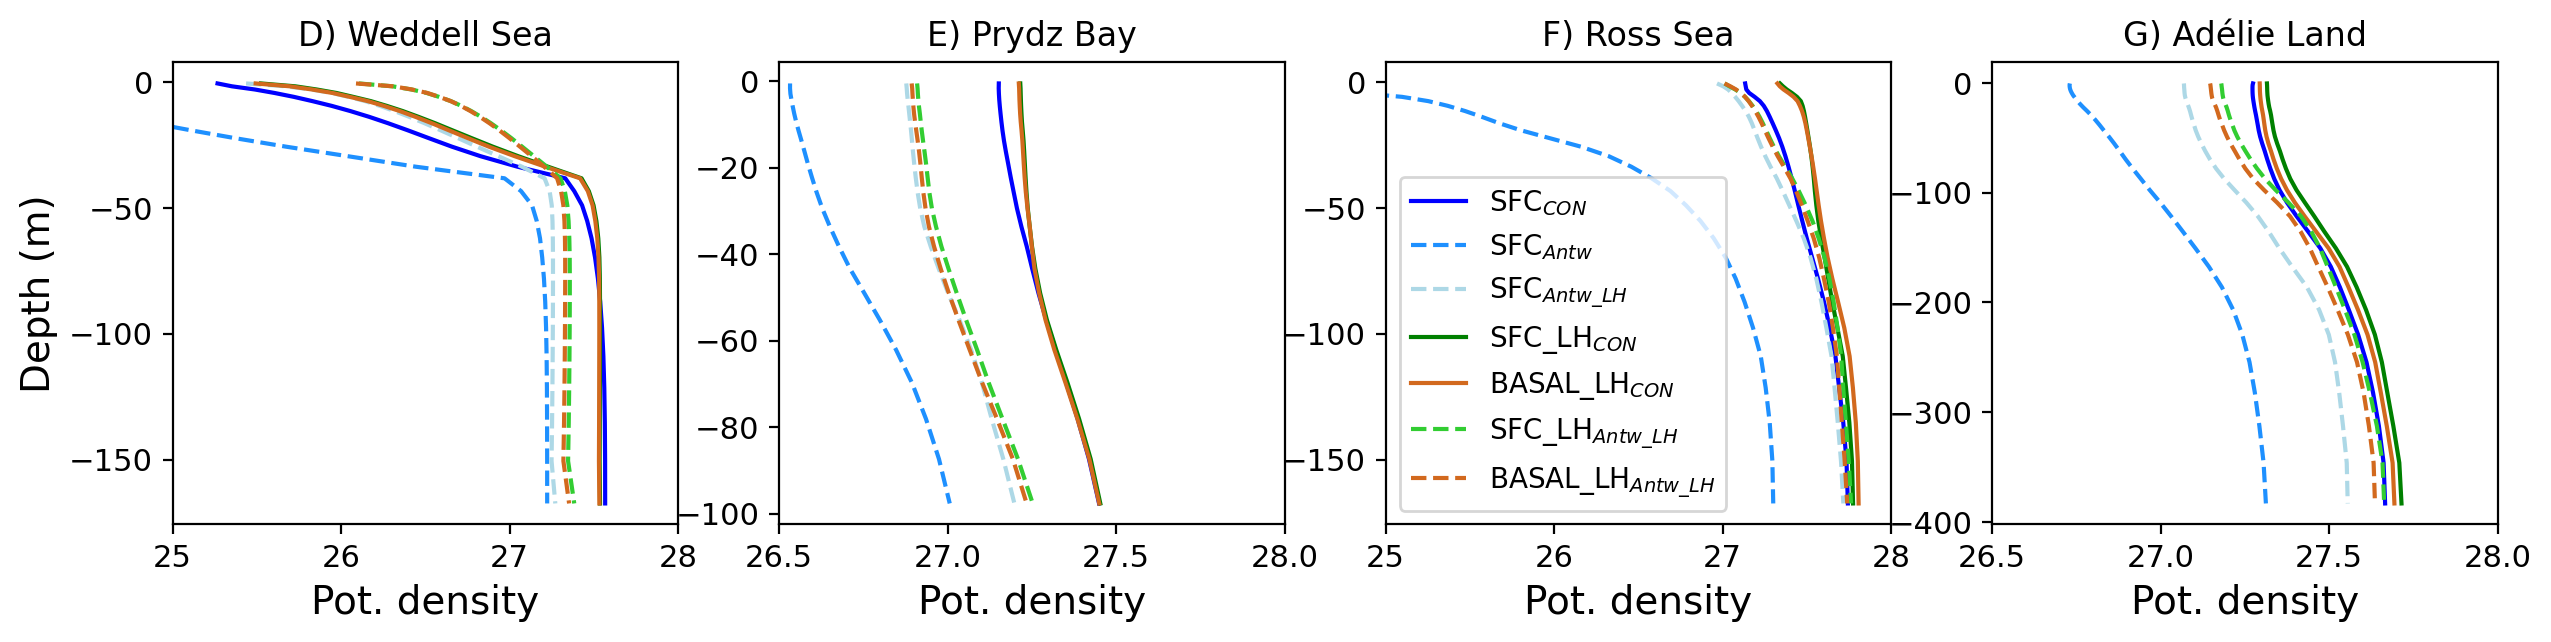

In [36]:
latlim = -77 # for Ross Sea

temp = abs_temp_profile['Ross Sea']['A'] - 273.15
salt = abs_salt_profile['Ross Sea']['A']
rhoA_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['B'] - 273.15
salt = abs_salt_profile['Ross Sea']['B']
rhoB_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['C'] - 273.15
salt = abs_salt_profile['Ross Sea']['C']
rhoC_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['D'] - 273.15
salt = abs_salt_profile['Ross Sea']['D']
rhoD_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['E'] - 273.15
salt = abs_salt_profile['Ross Sea']['E']
rhoE_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['F'] - 273.15
salt = abs_salt_profile['Ross Sea']['F']
rhoF_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['G'] - 273.15
salt = abs_salt_profile['Ross Sea']['G']
rhoG_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

fig, ax = plt.subplots(1,4, figsize=(15,3))

ax[2].set_title('F) Ross Sea')
ax[2].plot(rhoA_profile,-rhoA_profile.st_ocean,color='blue',linestyle='-',label='SFC$_{CON}$')
ax[2].plot(rhoD_profile,-rhoD_profile.st_ocean,color='dodgerblue',linestyle='--',label='SFC$_{Antw}$') 
ax[2].plot(rhoE_profile,-rhoE_profile.st_ocean,color='lightblue',linestyle='--',label='SFC$_{Antw\_LH}$')
ax[2].plot(rhoB_profile,-rhoB_profile.st_ocean,color='green',linestyle='-',label='SFC_LH$_{CON}$')
ax[2].plot(rhoC_profile,-rhoC_profile.st_ocean,color='chocolate',linestyle='-',label='BASAL_LH$_{CON}$')
ax[2].plot(rhoF_profile,-rhoF_profile.st_ocean,color='limegreen',linestyle='--',label='SFC_LH$_{Antw\_LH}$')
ax[2].plot(rhoG_profile,-rhoG_profile.st_ocean,color='chocolate',linestyle='--',label='BASAL_LH$_{Antw\_LH}$')
ax[2].legend(loc='lower left')
ax[2].set_xlim(25.5,28)

## Weddell ---------------------------------------
latlim = -77 # for Weddell Sea

temp = abs_temp_profile['Weddell Sea']['A'] - 273.15
salt = abs_salt_profile['Weddell Sea']['A']
rhoA_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['B'] - 273.15
salt = abs_salt_profile['Weddell Sea']['B']
rhoB_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['C'] - 273.15
salt = abs_salt_profile['Weddell Sea']['C']
rhoC_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['D'] - 273.15
salt = abs_salt_profile['Weddell Sea']['D']
rhoD_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['E'] - 273.15
salt = abs_salt_profile['Weddell Sea']['E']
rhoE_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['F'] - 273.15
salt = abs_salt_profile['Weddell Sea']['F']
rhoF_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['G'] - 273.15
salt = abs_salt_profile['Weddell Sea']['G']
rhoG_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

ax[0].set_title('D) Weddell Sea')
ax[0].plot(rhoA_profile,-rhoA_profile.st_ocean,color='blue',linestyle='-',label='SFC$_{CON}$')
ax[0].plot(rhoD_profile,-rhoD_profile.st_ocean,color='dodgerblue',linestyle='--',label='SFC_LH$_{CON}$')
ax[0].plot(rhoE_profile,-rhoE_profile.st_ocean,color='lightblue',linestyle='--',label='BASAL_LH$_{CON}$')
ax[0].plot(rhoB_profile,-rhoB_profile.st_ocean,color='green',linestyle='-',label='SFC$_{Antw}$')
ax[0].plot(rhoC_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle='-',label='SFC$_{Antw\_LH}$')
ax[0].plot(rhoF_profile,-rhoB_profile.st_ocean,color='limegreen',linestyle='--',label='SFC_LH$_{Antw\_LH}$')
ax[0].plot(rhoG_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle='--',label='BASAL_LH$_{Antw\_LH}$')
ax[0].set_xlim(25.,27.7)

## Adèlie ---------------------------------------
latlim = -66.3 # for Adélie Land

temp = abs_temp_profile['Adélie Land']['A'] - 273.15
salt = abs_salt_profile['Adélie Land']['A']
rhoA_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['B'] - 273.15
salt = abs_salt_profile['Adélie Land']['B']
rhoB_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['C'] - 273.15
salt = abs_salt_profile['Adélie Land']['C']
rhoC_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['D'] - 273.15
salt = abs_salt_profile['Adélie Land']['D']
rhoD_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['E'] - 273.15
salt = abs_salt_profile['Adélie Land']['E']
rhoE_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['F'] - 273.15
salt = abs_salt_profile['Adélie Land']['F']
rhoF_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['G'] - 273.15
salt = abs_salt_profile['Adélie Land']['G']
rhoG_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

ax[3].set_title('G) Adélie Land')
ax[3].plot(rhoA_profile,-rhoA_profile.st_ocean,color='blue',linestyle='-',label='SFC$_{CON}$')
ax[3].plot(rhoD_profile,-rhoD_profile.st_ocean,color='dodgerblue',linestyle='--',label='SFC_LH$_{CON}$')
ax[3].plot(rhoE_profile,-rhoE_profile.st_ocean,color='lightblue',linestyle='--',label='BASAL_LH$_{CON}$')
ax[3].plot(rhoB_profile,-rhoB_profile.st_ocean,color='green',linestyle='-',label='SFC$_{Antw}$')
ax[3].plot(rhoC_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle='-',label='SFC$_{Antw\_LH}$')
ax[3].plot(rhoF_profile,-rhoB_profile.st_ocean,color='limegreen',linestyle='--',label='SFC_LH$_{Antw\_LH}$')
ax[3].plot(rhoG_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle='--',label='BASAL_LH$_{Antw\_LH}$')
ax[3].set_xlim(27.,28)

## Prydz ---------------------------------------
latlim = -67.5 # for Prydz Bay

temp = abs_temp_profile['Prydz Bay']['A'] - 273.15
salt = abs_salt_profile['Prydz Bay']['A']
rhoA_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['B'] - 273.15
salt = abs_salt_profile['Prydz Bay']['B']
rhoB_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['C'] - 273.15
salt = abs_salt_profile['Prydz Bay']['C']
rhoC_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['D'] - 273.15
salt = abs_salt_profile['Prydz Bay']['D']
rhoD_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['E'] - 273.15
salt = abs_salt_profile['Prydz Bay']['E']
rhoE_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['F'] - 273.15
salt = abs_salt_profile['Prydz Bay']['F']
rhoF_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['G'] - 273.15
salt = abs_salt_profile['Prydz Bay']['G']
rhoG_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

ax[1].set_title('E) Prydz Bay')
ax[1].plot(rhoA_profile,-rhoA_profile.st_ocean,color='blue',linestyle='-',label='SFC$_{CON}$')
ax[1].plot(rhoD_profile,-rhoD_profile.st_ocean,color='dodgerblue',linestyle='--',label='SFC_LH$_{CON}$')
ax[1].plot(rhoE_profile,-rhoE_profile.st_ocean,color='lightblue',linestyle='--',label='BASAL_LH$_{CON}$')
ax[1].plot(rhoB_profile,-rhoB_profile.st_ocean,color='green',linestyle='-',label='SFC$_{Antw}$')
ax[1].plot(rhoC_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle='-',label='SFC$_{Antw\_LH}$')
ax[1].plot(rhoF_profile,-rhoB_profile.st_ocean,color='limegreen',linestyle='--',label='SFC_LH$_{Antw\_LH}$')
ax[1].plot(rhoG_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle='--',label='BASAL_LH$_{Antw\_LH}$')
ax[1].set_xlim(27.,28)

ax[0].set_ylabel('Depth (m)',fontsize=14)

for nn in range(4):
    ax[nn].set_xlabel('Pot. density',fontsize=14)
    ax[nn].tick_params(labelsize=11)

ax[0].set_xlim(25.,28)
ax[2].set_xlim(25.,28)
ax[1].set_xlim(26.5,28)
ax[3].set_xlim(26.5,28)

plt.savefig(
        f"{figdir}Density_vertical_profiles_annual.png",
        bbox_inches='tight',
        dpi=300
    )

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 32.74 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 25.23 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/cli

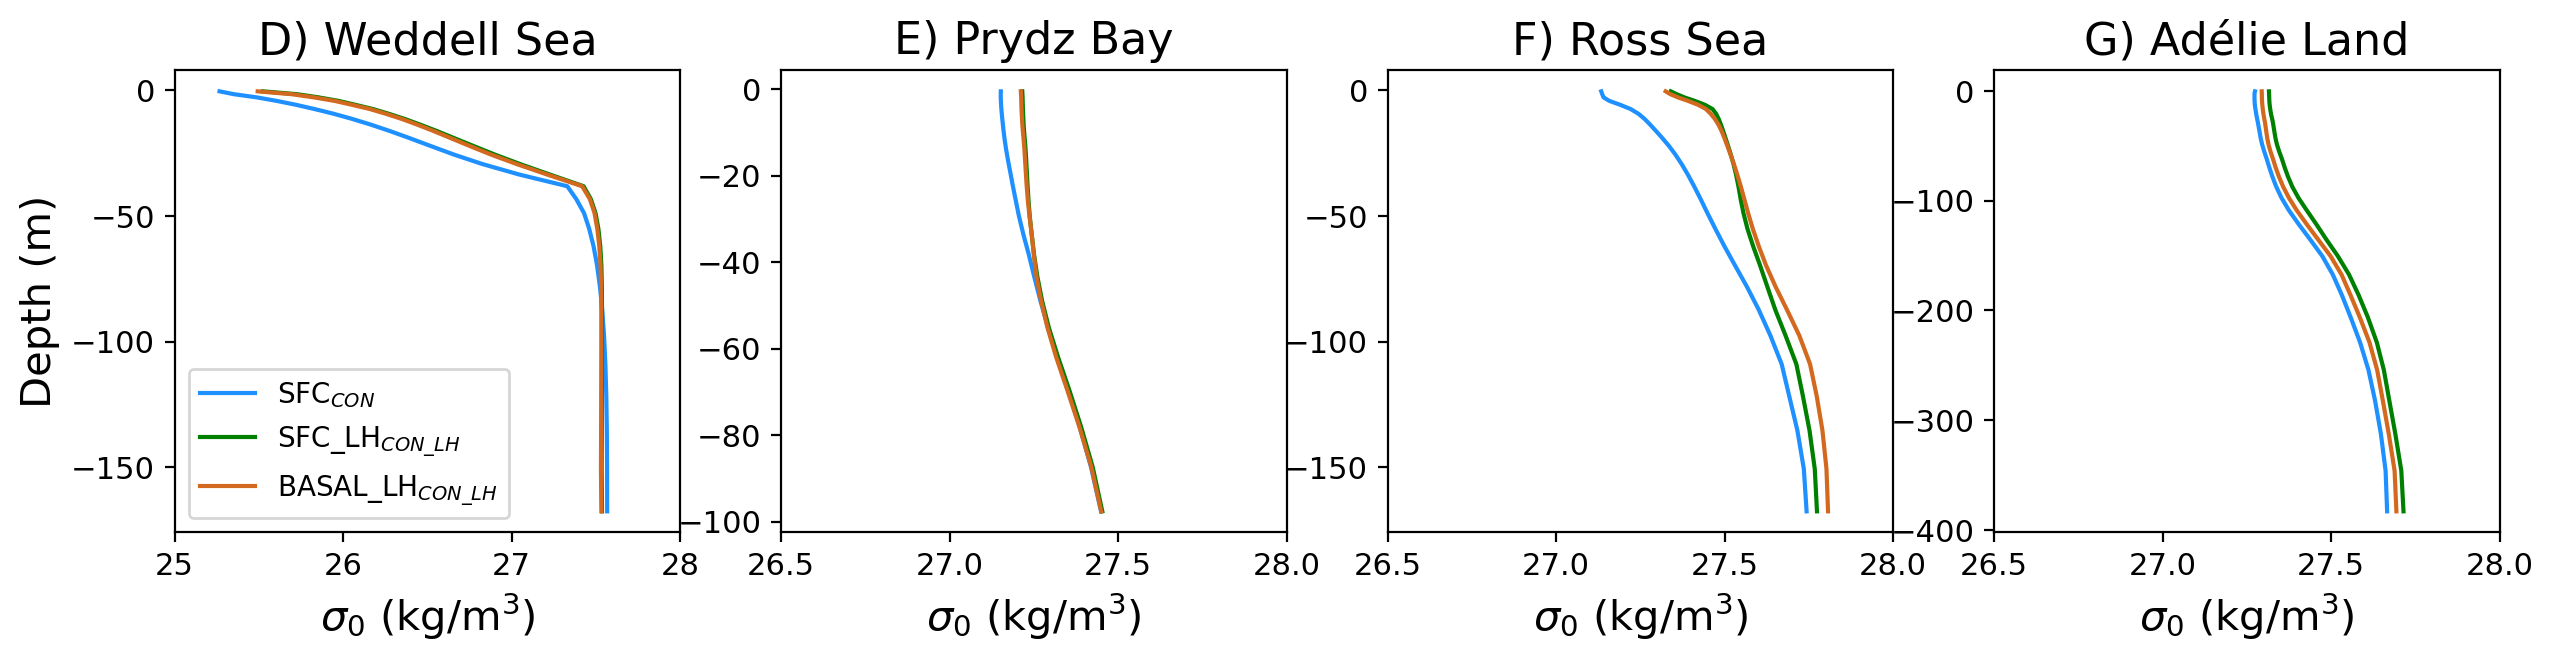

In [43]:
latlim = -77 # for Ross Sea

temp = abs_temp_profile['Ross Sea']['A'] - 273.15
salt = abs_salt_profile['Ross Sea']['A']
rhoA_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['B'] - 273.15
salt = abs_salt_profile['Ross Sea']['B']
rhoB_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['C'] - 273.15
salt = abs_salt_profile['Ross Sea']['C']
rhoC_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['D'] - 273.15
salt = abs_salt_profile['Ross Sea']['D']
rhoD_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['E'] - 273.15
salt = abs_salt_profile['Ross Sea']['E']
rhoE_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['F'] - 273.15
salt = abs_salt_profile['Ross Sea']['F']
rhoF_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Ross Sea']['G'] - 273.15
salt = abs_salt_profile['Ross Sea']['G']
rhoG_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

fig, ax = plt.subplots(1,4, figsize=(15,3))

ax[2].set_title('F) Ross Sea',fontsize=16)
ax[2].plot(rhoA_profile,-rhoA_profile.st_ocean,color='dodgerblue',linestyle='-',label='SFC$_{CON}$')
# ax[2].plot(rhoD_profile,-rhoD_profile.st_ocean,color='dodgerblue',linestyle='--',label='SFC$_{Antw}$') 
# ax[2].plot(rhoE_profile,-rhoE_profile.st_ocean,color='lightblue',linestyle='--',label='SFC$_{Antw\_LH}$')
ax[2].plot(rhoB_profile,-rhoB_profile.st_ocean,color='green',linestyle='-',label='SFC_LH$_{CON}$')
ax[2].plot(rhoC_profile,-rhoC_profile.st_ocean,color='chocolate',linestyle='-',label='BASAL_LH$_{CON}$')
# ax[2].plot(rhoF_profile,-rhoF_profile.st_ocean,color='limegreen',linestyle='--',label='SFC_LH$_{Antw\_LH}$')
# ax[2].plot(rhoG_profile,-rhoG_profile.st_ocean,color='chocolate',linestyle='--',label='BASAL_LH$_{Antw\_LH}$')

## Weddell ---------------------------------------
latlim = -77 # for Weddell Sea

temp = abs_temp_profile['Weddell Sea']['A'] - 273.15
salt = abs_salt_profile['Weddell Sea']['A']
rhoA_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['B'] - 273.15
salt = abs_salt_profile['Weddell Sea']['B']
rhoB_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['C'] - 273.15
salt = abs_salt_profile['Weddell Sea']['C']
rhoC_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['D'] - 273.15
salt = abs_salt_profile['Weddell Sea']['D']
rhoD_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['E'] - 273.15
salt = abs_salt_profile['Weddell Sea']['E']
rhoE_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['F'] - 273.15
salt = abs_salt_profile['Weddell Sea']['F']
rhoF_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Weddell Sea']['G'] - 273.15
salt = abs_salt_profile['Weddell Sea']['G']
rhoG_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

ax[0].set_title('D) Weddell Sea',fontsize=16)
ax[0].plot(rhoA_profile,-rhoA_profile.st_ocean,color='dodgerblue',linestyle='-',label='SFC$_{CON}$')
# ax[0].plot(rhoD_profile,-rhoD_profile.st_ocean,color='dodgerblue',linestyle='--',label='SFC_LH$_{CON}$')
# ax[0].plot(rhoE_profile,-rhoE_profile.st_ocean,color='lightblue',linestyle=':',label='BASAL_LH$_{CON}$')
ax[0].plot(rhoB_profile,-rhoB_profile.st_ocean,color='green',linestyle='-',label='SFC_LH$_{CON\_LH}$')
ax[0].plot(rhoC_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle='-',label='BASAL_LH$_{CON\_LH}$')
# ax[0].plot(rhoF_profile,-rhoB_profile.st_ocean,color='limegreen',linestyle='--',label='SFC_LH$_{Antw\_LH}$')
# ax[0].plot(rhoG_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle=':',label='BASAL_LH$_{Antw\_LH}$')
ax[0].legend(loc='lower left')

## Adèlie ---------------------------------------
latlim = -66.3 # for Adélie Land

temp = abs_temp_profile['Adélie Land']['A'] - 273.15
salt = abs_salt_profile['Adélie Land']['A']
rhoA_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['B'] - 273.15
salt = abs_salt_profile['Adélie Land']['B']
rhoB_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['C'] - 273.15
salt = abs_salt_profile['Adélie Land']['C']
rhoC_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['D'] - 273.15
salt = abs_salt_profile['Adélie Land']['D']
rhoD_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['E'] - 273.15
salt = abs_salt_profile['Adélie Land']['E']
rhoE_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['F'] - 273.15
salt = abs_salt_profile['Adélie Land']['F']
rhoF_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Adélie Land']['G'] - 273.15
salt = abs_salt_profile['Adélie Land']['G']
rhoG_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

ax[3].set_title('G) Adélie Land',fontsize=16)
ax[3].plot(rhoA_profile,-rhoA_profile.st_ocean,color='dodgerblue',linestyle='-',label='SFC$_{CON}$')
# ax[3].plot(rhoD_profile,-rhoD_profile.st_ocean,color='dodgerblue',linestyle='--',label='SFC_LH$_{CON}$')
# ax[3].plot(rhoE_profile,-rhoE_profile.st_ocean,color='lightblue',linestyle=':',label='BASAL_LH$_{CON}$')
ax[3].plot(rhoB_profile,-rhoB_profile.st_ocean,color='green',linestyle='-',label='SFC$_{Antw}$')
ax[3].plot(rhoC_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle='-',label='SFC$_{Antw\_LH}$')
# ax[3].plot(rhoF_profile,-rhoB_profile.st_ocean,color='limegreen',linestyle='--',label='SFC_LH$_{Antw\_LH}$')
# ax[3].plot(rhoG_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle=':',label='BASAL_LH$_{Antw\_LH}$')

## Prydz ---------------------------------------
latlim = -67.5 # for Prydz Bay

temp = abs_temp_profile['Prydz Bay']['A'] - 273.15
salt = abs_salt_profile['Prydz Bay']['A']
rhoA_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['B'] - 273.15
salt = abs_salt_profile['Prydz Bay']['B']
rhoB_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['C'] - 273.15
salt = abs_salt_profile['Prydz Bay']['C']
rhoC_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['D'] - 273.15
salt = abs_salt_profile['Prydz Bay']['D']
rhoD_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['E'] - 273.15
salt = abs_salt_profile['Prydz Bay']['E']
rhoE_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['F'] - 273.15
salt = abs_salt_profile['Prydz Bay']['F']
rhoF_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

temp = abs_temp_profile['Prydz Bay']['G'] - 273.15
salt = abs_salt_profile['Prydz Bay']['G']
rhoG_profile = calc_rho_profile(temp,salt,temp.yt_ocean)

ax[1].set_title('E) Prydz Bay',fontsize=16)
ax[1].plot(rhoA_profile,-rhoA_profile.st_ocean,color='dodgerblue',linestyle='-',label='SFC$_{CON}$')
# ax[1].plot(rhoD_profile,-rhoD_profile.st_ocean,color='dodgerblue',linestyle='--',label='SFC_LH$_{CON}$')
# ax[1].plot(rhoE_profile,-rhoE_profile.st_ocean,color='lightblue',linestyle=':',label='BASAL_LH$_{CON}$')
ax[1].plot(rhoB_profile,-rhoB_profile.st_ocean,color='green',linestyle='-',label='SFC$_{Antw}$')
ax[1].plot(rhoC_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle='-',label='SFC$_{Antw\_LH}$')
# ax[1].plot(rhoF_profile,-rhoB_profile.st_ocean,color='limegreen',linestyle='--',label='SFC_LH$_{Antw\_LH}$')
# ax[1].plot(rhoG_profile,-rhoB_profile.st_ocean,color='chocolate',linestyle=':',label='BASAL_LH$_{Antw\_LH}$')
ax[1].set_xlim(27.,28)

ax[0].set_ylabel('Depth (m)',fontsize=15)

for nn in range(4):
    ax[nn].set_xlabel('$\sigma_{0}$ (kg/m$^3$)',fontsize=15)
    ax[nn].tick_params(labelsize=11)

ax[0].set_xlim(25.,28)
ax[2].set_xlim(26.5,28)
ax[1].set_xlim(26.5,28)
ax[3].set_xlim(26.5,28)


plt.savefig(
        f"{figdir}Density_vertical_profiles_annual_v2.png",
        bbox_inches='tight',
        dpi=300
    )